# SOLA Method with Noise: Unimodular Property Inference Demo

This notebook mirrors the interval-domain SOLA noise demo, but keeps only the **unimodular** branch of the construction.

We work with:
- a model space $\mathcal{M}$ on the interval $[0,1]$,
- a forward operator $G : \mathcal{M} \to \mathcal{D}$ built from sensitivity kernels,
- a target/property operator $\mathcal{T} : \mathcal{M} \to \mathcal{P}$ built from localized bump kernels.

The SOLA operator is first assembled as

$$
X = \mathcal{T} G^* (G G^* + C_D)^{-1},
$$

and then corrected to satisfy the unimodularity constraint so that constant models map to constant property values.

In [1]:
from intervalinf.providers import (
    NormalModesProvider,
    BumpFunctionProvider,
    BoxCarFunctionProvider,
    CustomBasisProvider,
 )
from intervalinf import IntervalDomain, Lebesgue, Function
from intervalinf.operators import SOLAOperator
from pygeoinf import (
    EuclideanSpace,
    LinearOperator,
    CholeskySolver,
    GaussianMeasure,
    MassWeightedHilbertSpace,
 )
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

np.random.seed(42)

figures_folder = 'sola_demo_figures'
os.makedirs(figures_folder, exist_ok=True)

## Spaces, Operators, and Kernel Families

We use the same model, data, and property construction as the original intervalinf demo:

- $\mathcal{M}$ is an $L^2$ model space on $[0,1]$,
- $G$ is built from random normal-mode sensitivity kernels,
- $\mathcal{T}$ is built from localized bump-function target kernels.

In [2]:
function_domain = IntervalDomain(0, 1)

M = Lebesgue(0, function_domain, basis=None)
N_d = 100
D = EuclideanSpace(N_d)
N_p = 20
P = EuclideanSpace(N_p)

width = 0.2
centers = np.linspace(
    function_domain.a + width / 2,
    function_domain.b - width / 2,
    N_p,
)

normal_modes_provider = NormalModesProvider(
    M,
    n_modes_range=(1, 50),
    coeff_range=(-5, 5),
    gaussian_width_percent_range=(1, 5),
    freq_range=(0.1, 20),
    random_state=2,
 )
G = SOLAOperator(M, D, kernels=normal_modes_provider)

target_provider = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(M, P, kernels=target_provider)

x = np.linspace(function_domain.a, function_domain.b, 1000)

print(f'Model space: {M}')
print(f'Data space dimension: {N_d}')
print(f'Property space dimension: {N_p}')

Model space: <intervalinf.spaces.lebesgue.Lebesgue object at 0x7f5edcba5710>
Data space dimension: 100
Property space dimension: 20


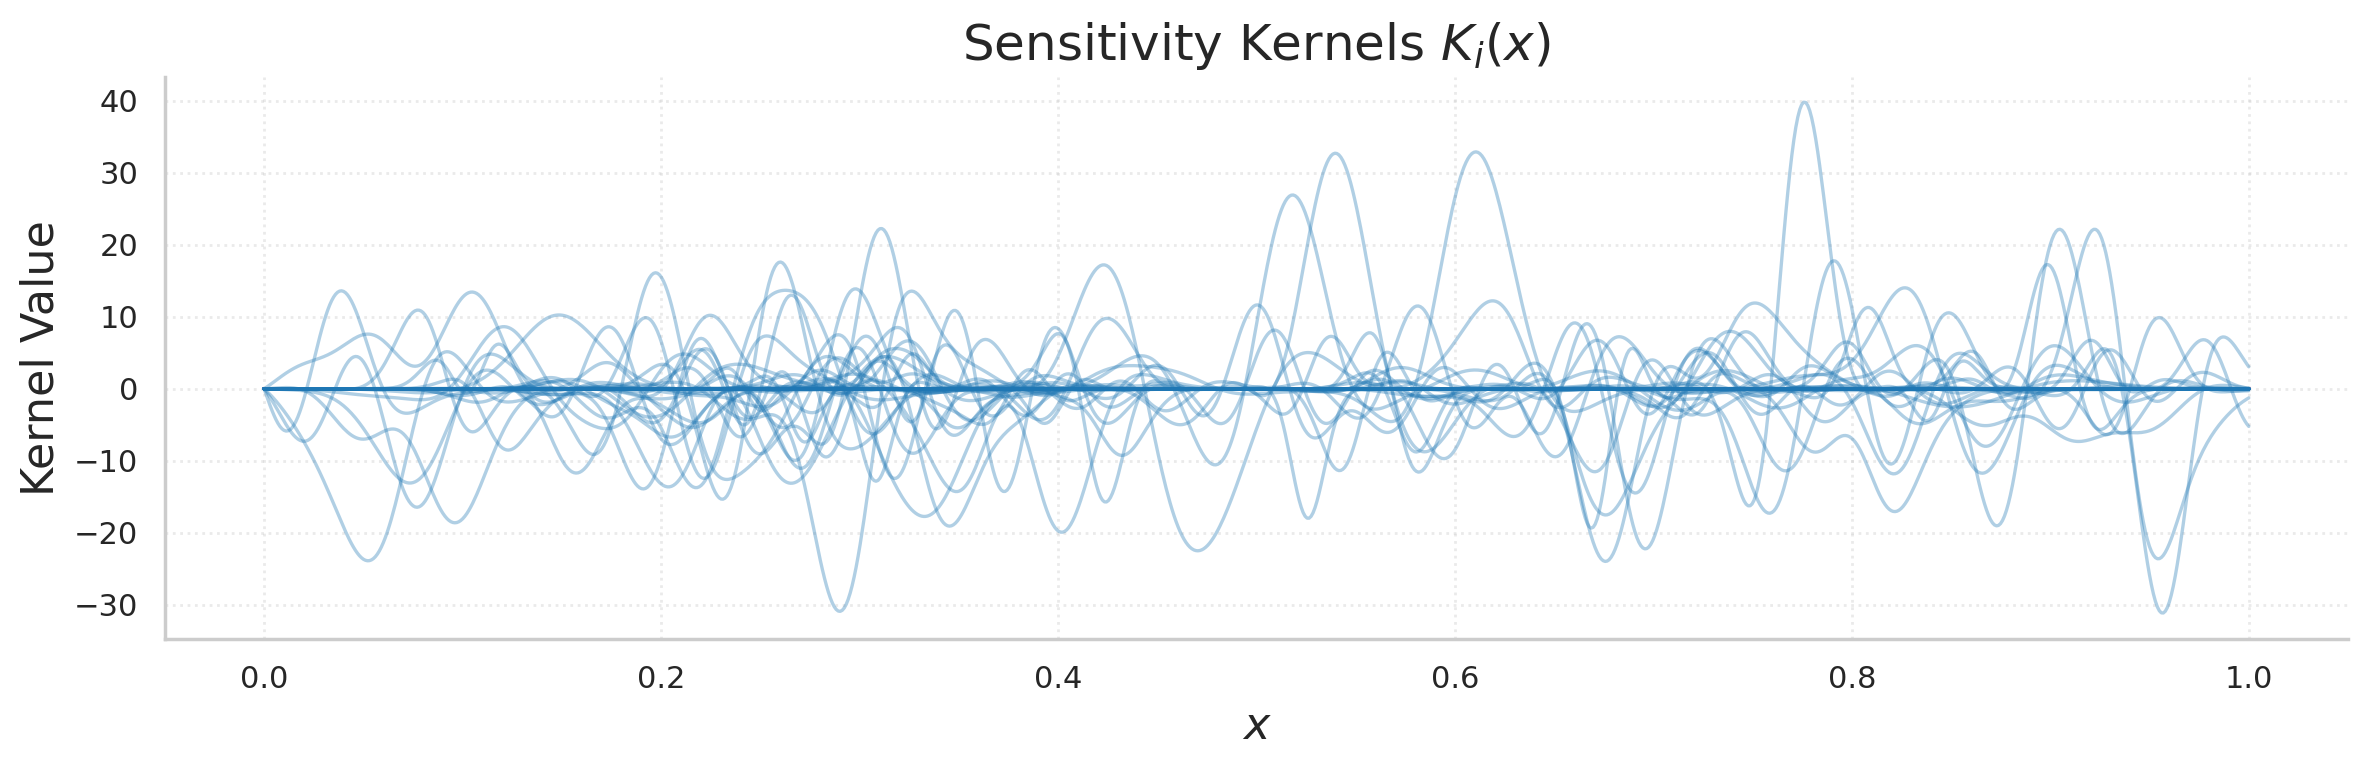

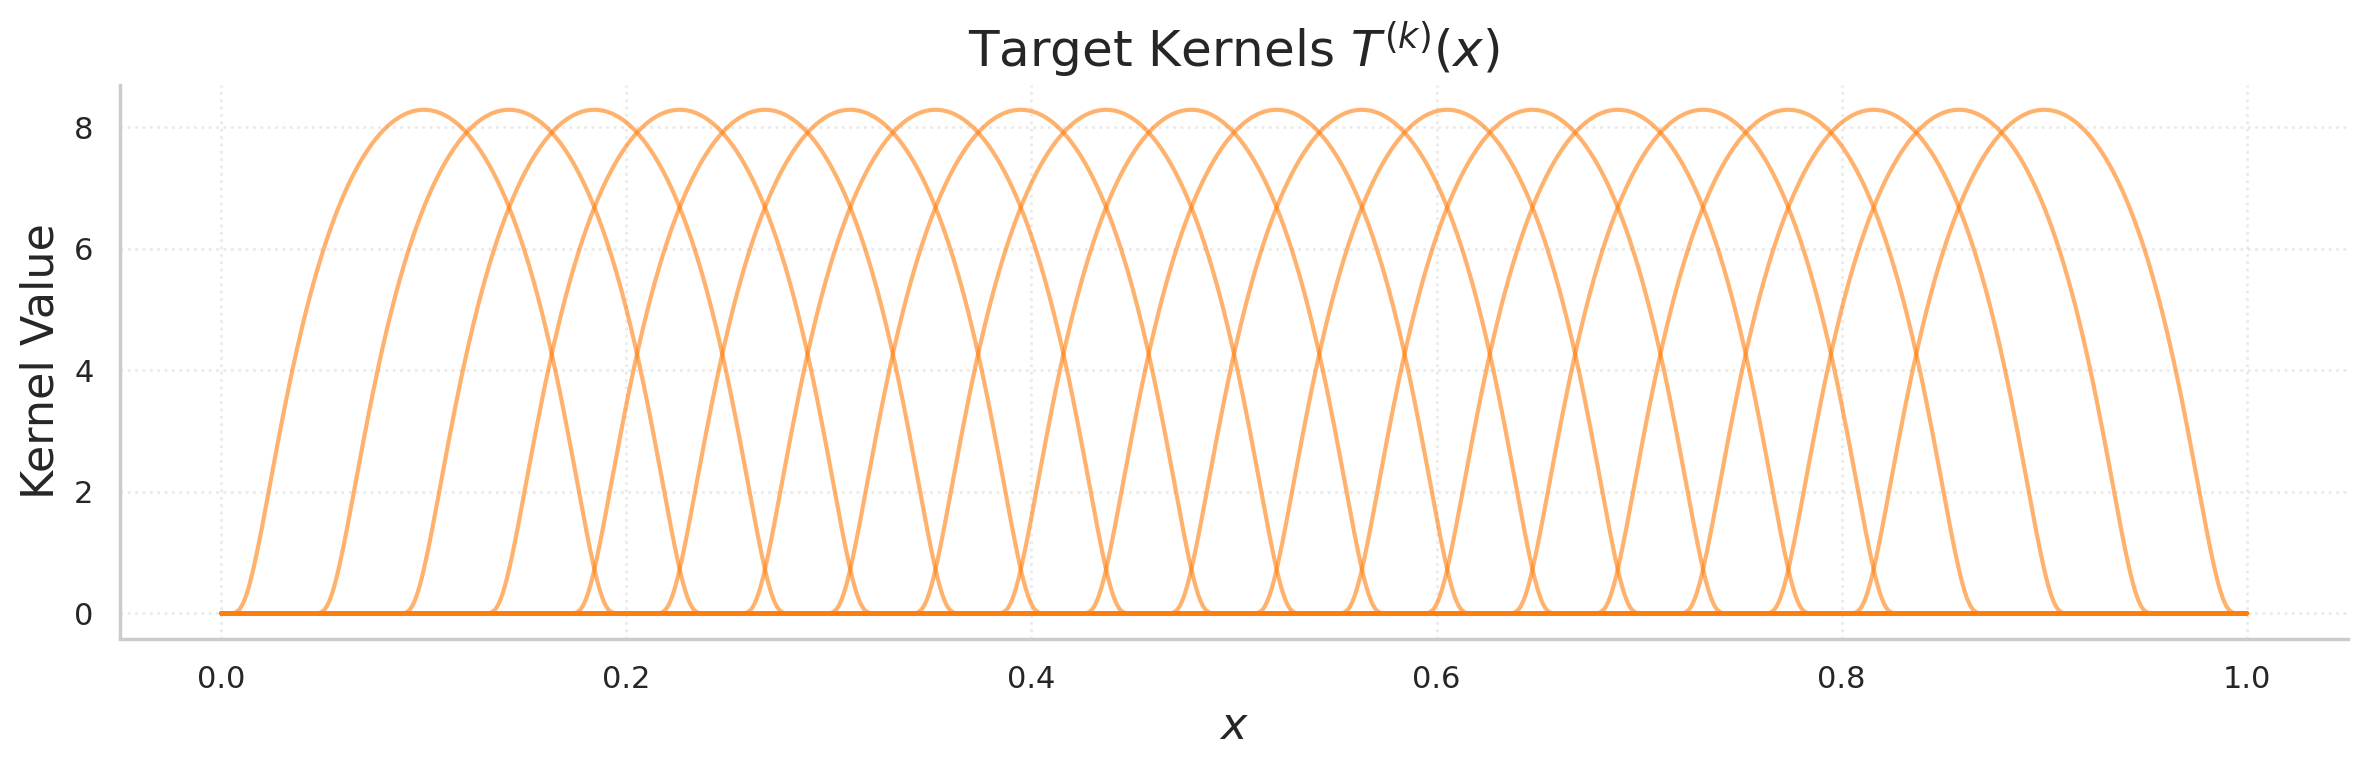

In [3]:
sns.set_theme(style='whitegrid', palette='muted', color_codes=True)

fig_title = 'Sensitivity Kernels'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_d):
    plt.plot(
        x,
        G.get_kernel(i).evaluate(x),
        color='tab:blue',
        alpha=0.35,
        linewidth=1.2,
    )
plt.title(r'Sensitivity Kernels $K_i(x)$', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Kernel Value', fontsize=16)
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

fig_title = 'Target Kernels'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_p):
    plt.plot(
        x,
        T.get_kernel(i).evaluate(x),
        color='tab:orange',
        alpha=0.6,
        linewidth=1.5,
    )
plt.title(r'Target Kernels $T^{(k)}(x)$', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Kernel Value', fontsize=16)
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Synthetic Model, Data Noise, and Reconstruction

We generate noisy observations from a smooth synthetic model, build the regularized SOLA operator, and compute the least-norm reconstruction associated with the data.

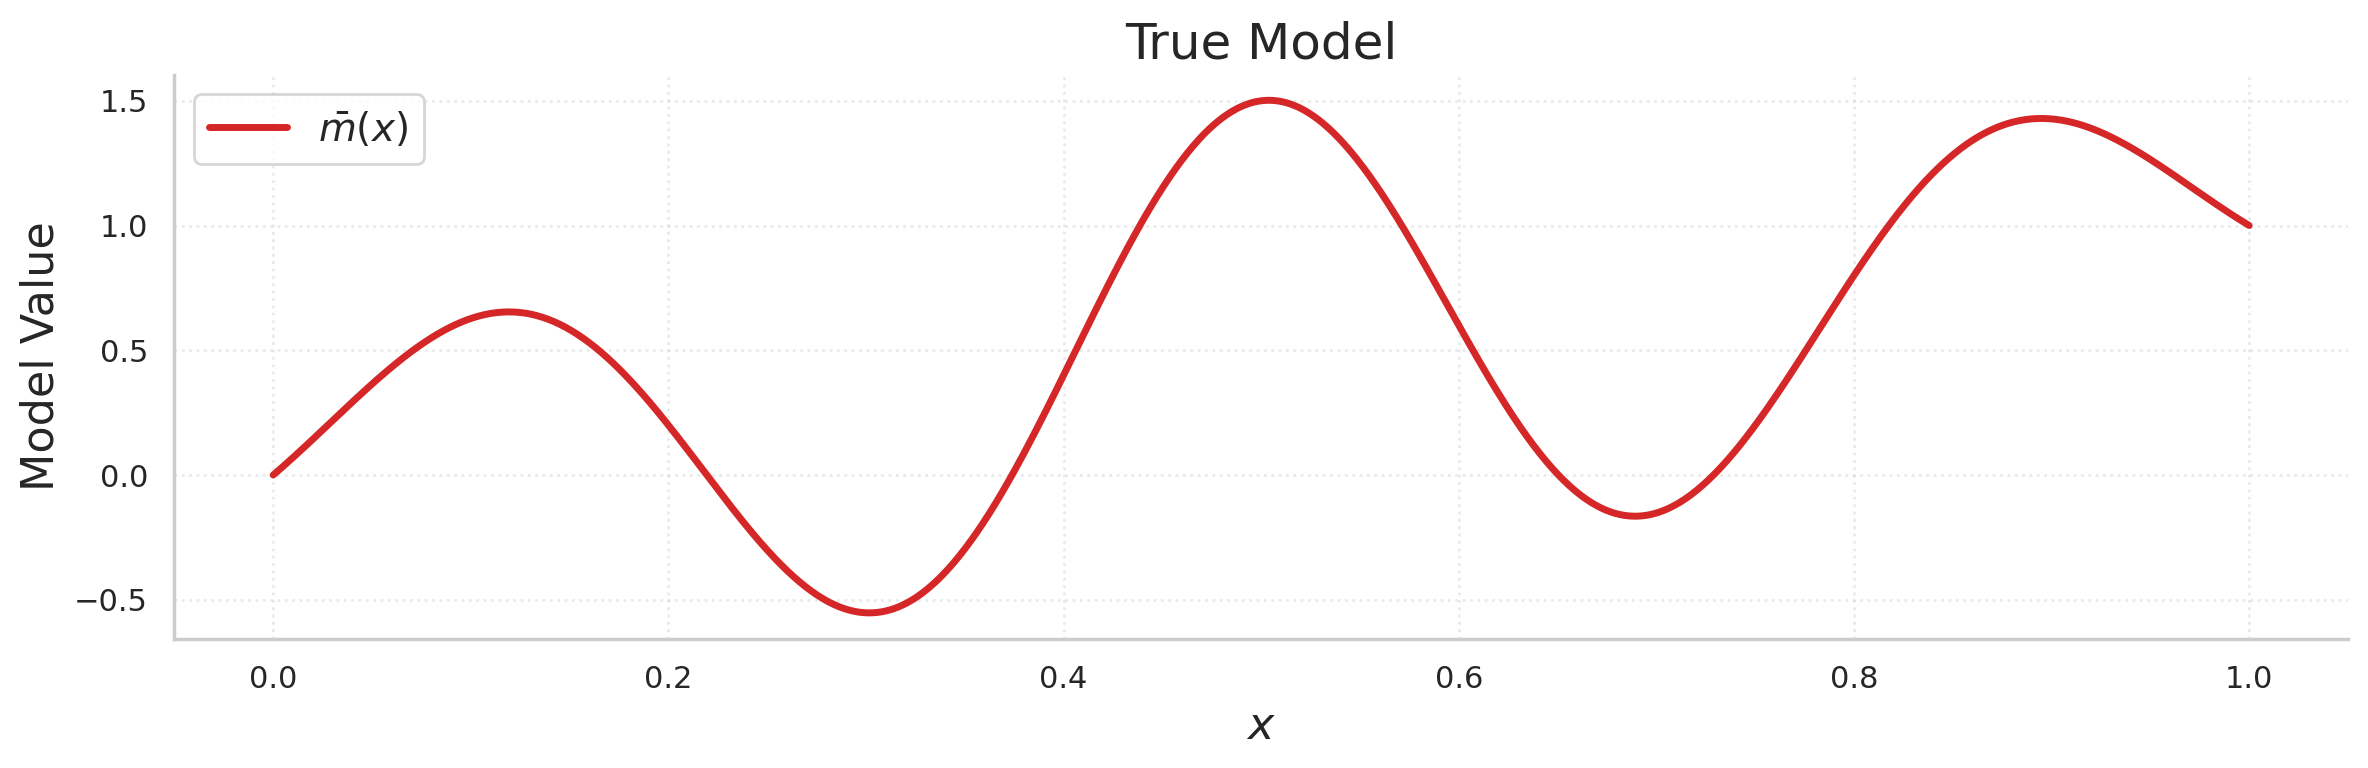

Signal-to-noise ratio: 10.0
Number of observations: 100
Data noise standard deviation: 0.1111


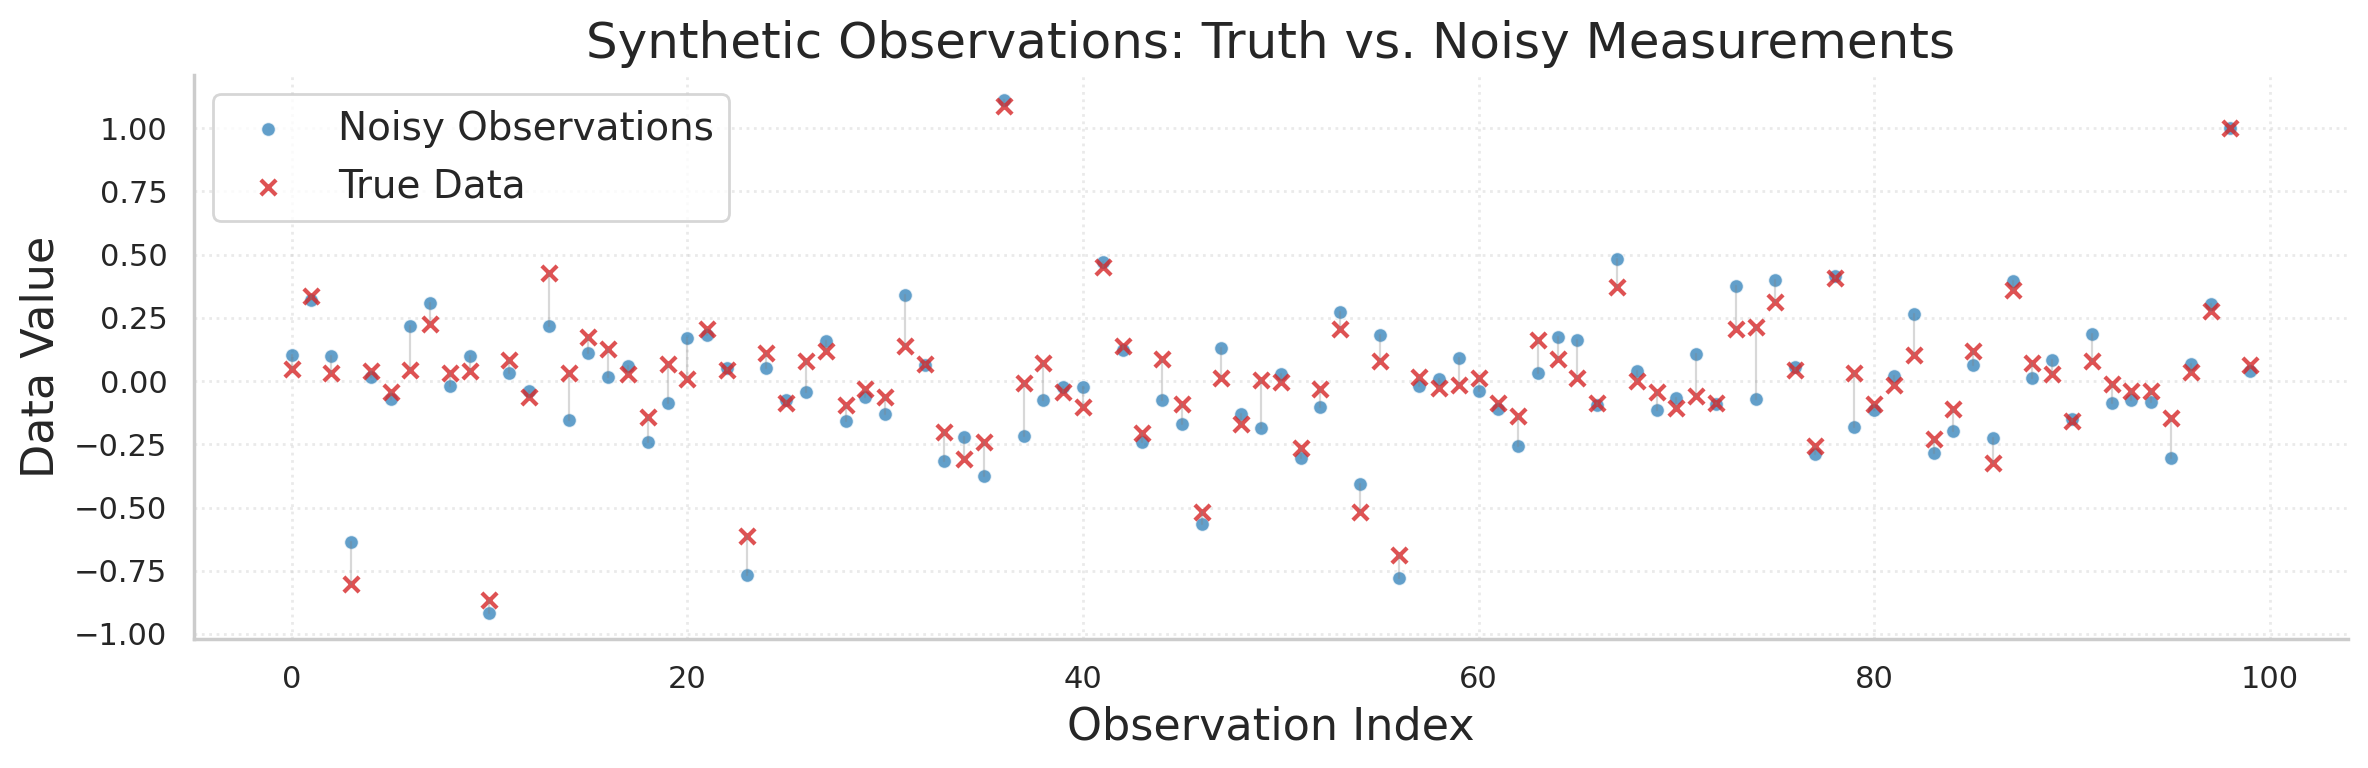

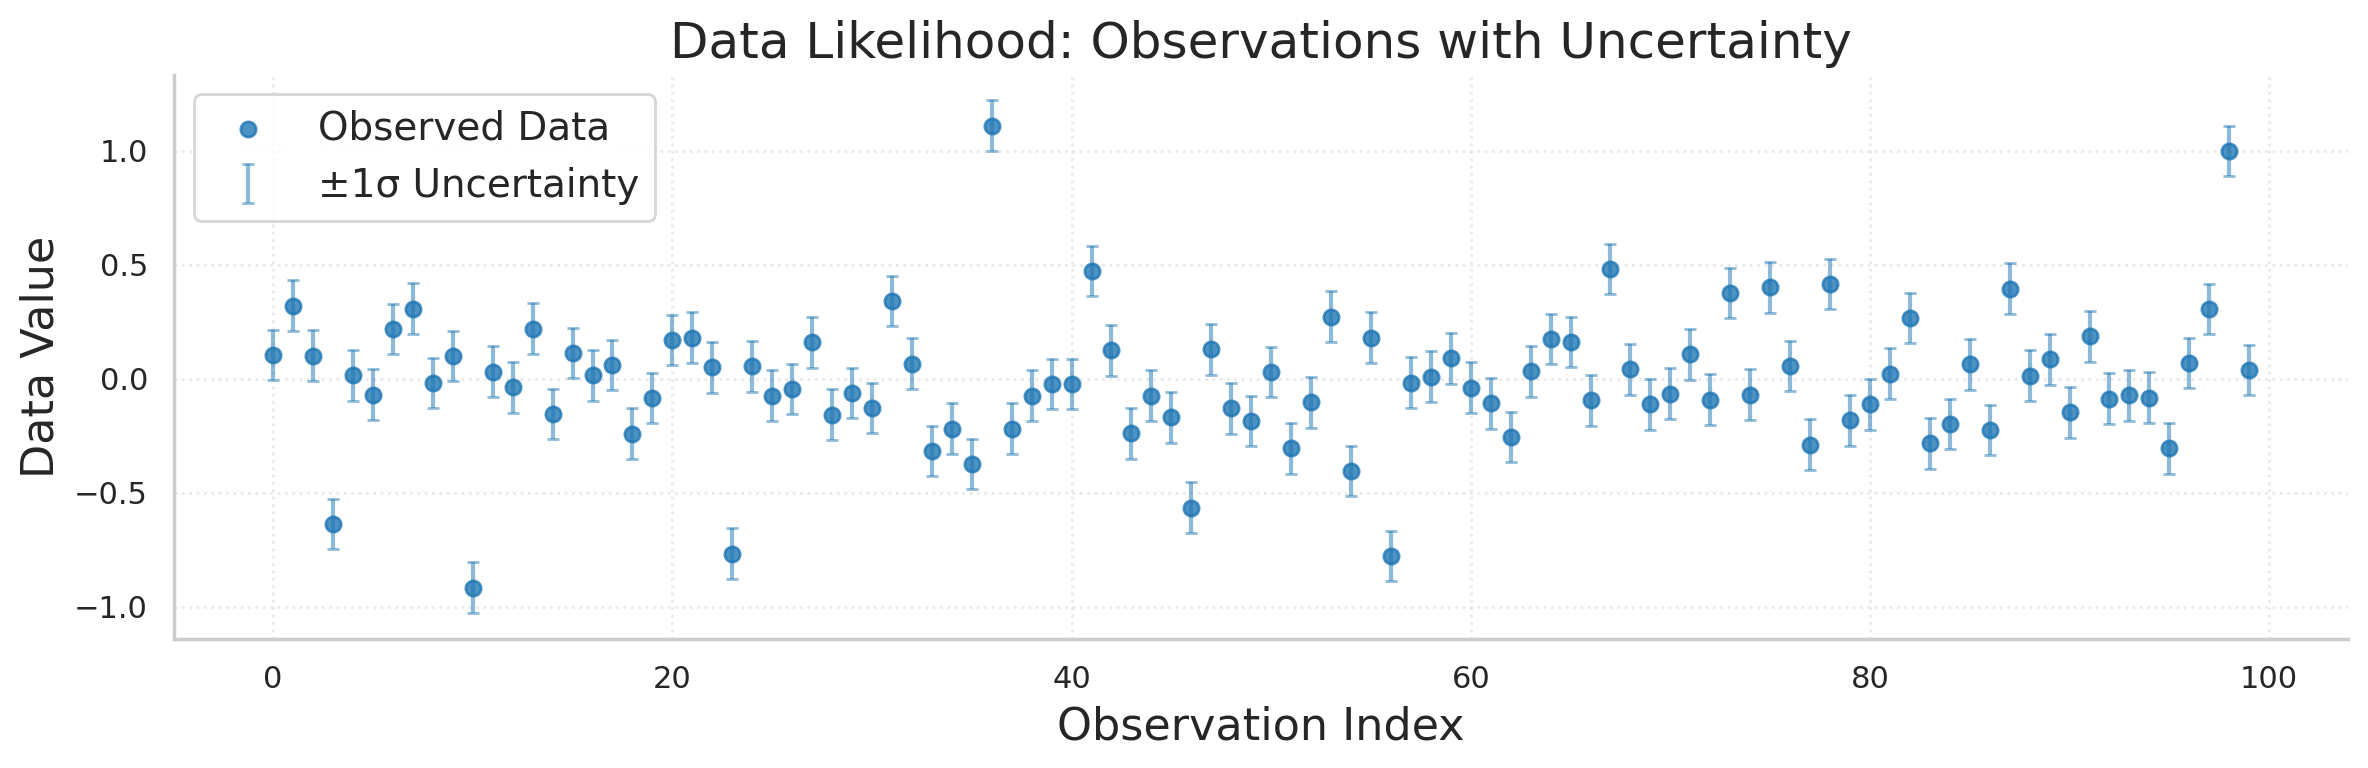

Computing SOLA operator...
✓ SOLA operator construction complete!
Norm reconstruction error: 1.9211
Relative error: 233.2%
Data misfit: 0.5468
Relative data misfit: 18.7%


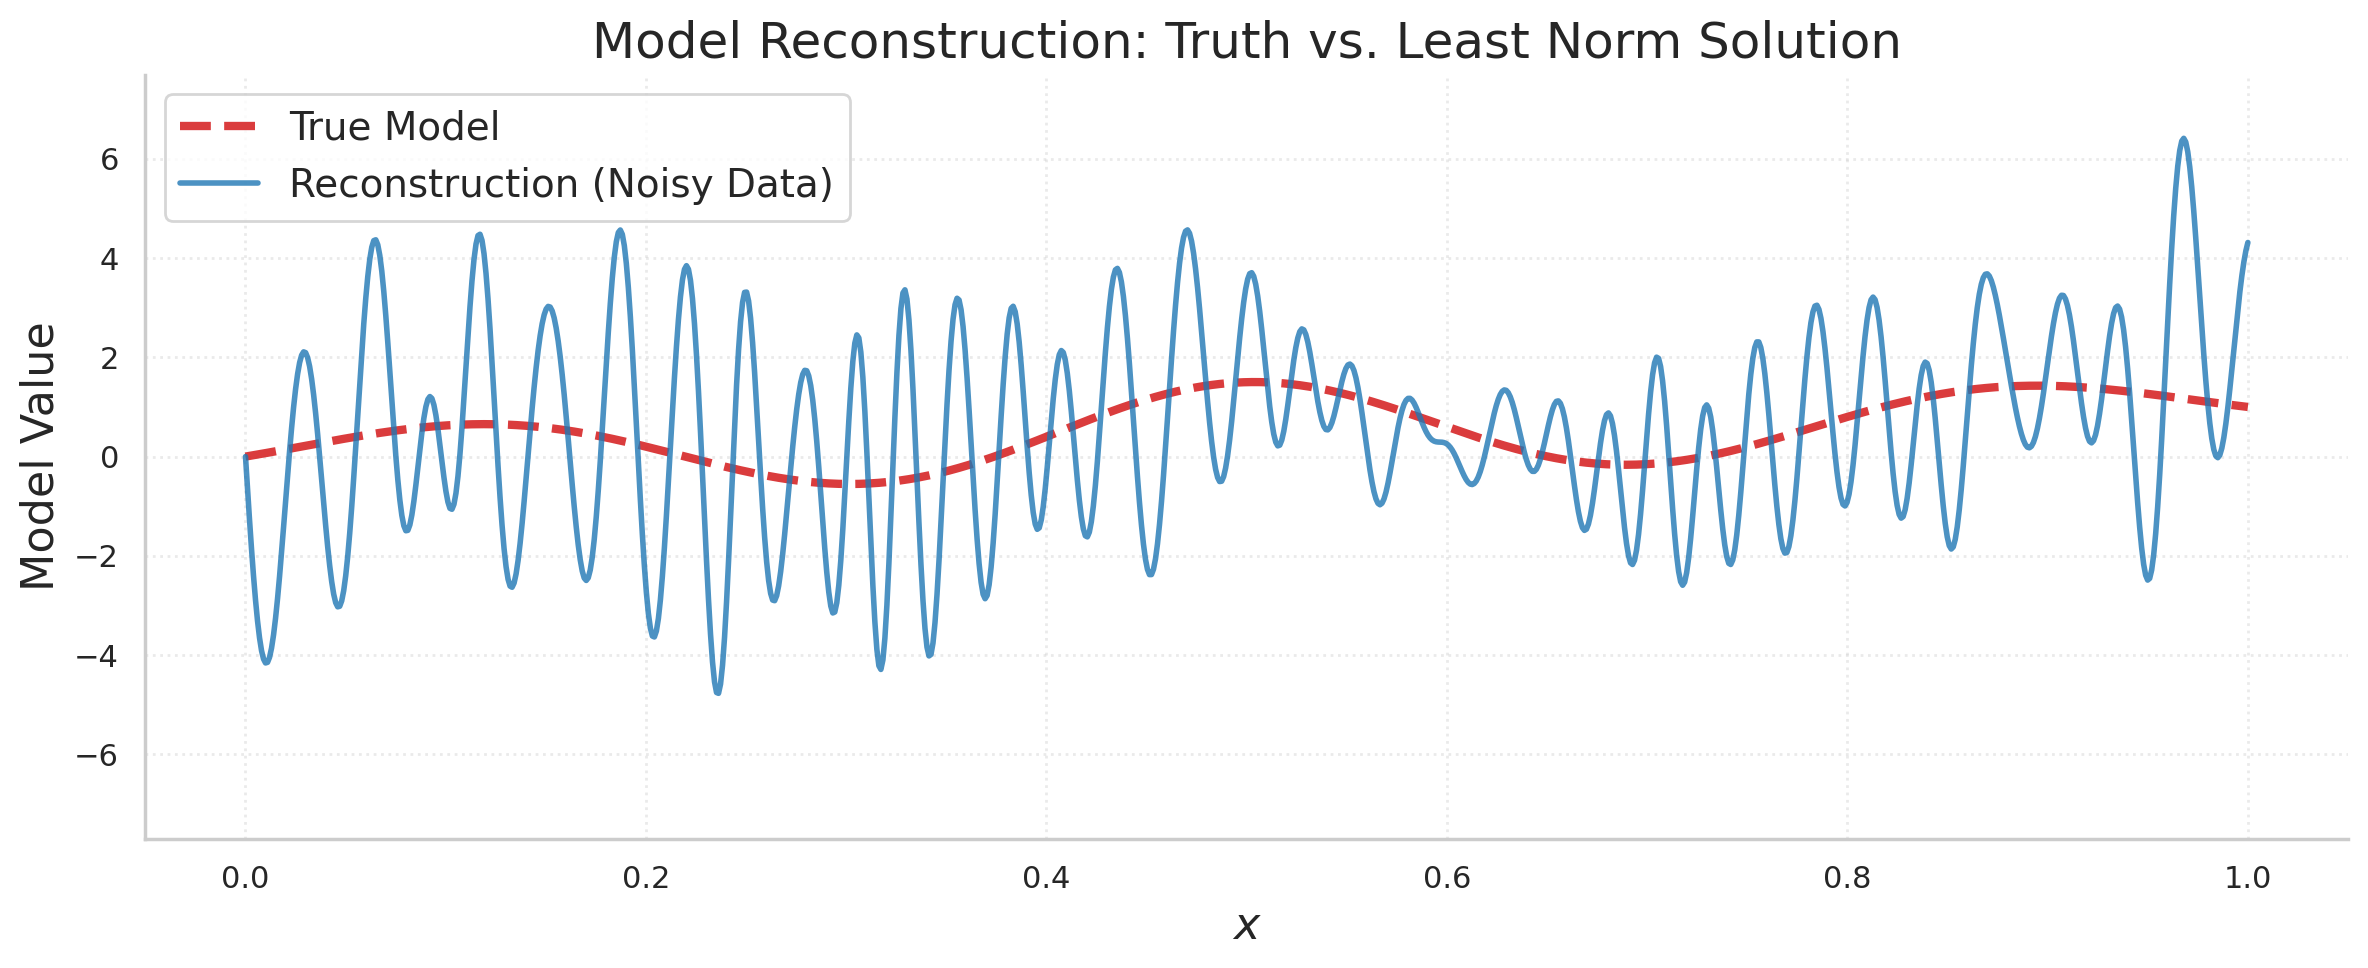

In [4]:
m_bar = Function(
    M,
    evaluate_callable=lambda x: np.exp(-((x - function_domain.center) / 0.5) ** 2) * np.sin(5 * np.pi * x) + x,
 )

fig_title = 'True Model'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label=r'$\bar{m}(x)$')
plt.title('True Model', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

d_bar = G(m_bar)
noise_level = 0.1 * np.max(d_bar)
np.random.seed(42)
d_tilde = d_bar + np.random.normal(0, noise_level, d_bar.shape)

noise_variance = (0.1 * np.max(d_tilde)) ** 2
C_D_matrix = noise_variance * np.eye(N_d)
gaussian_D_noise = GaussianMeasure.from_covariance_matrix(
    D, C_D_matrix, expectation=np.zeros(N_d)
 )
gaussian_D = GaussianMeasure.from_covariance_matrix(
    D, C_D_matrix, expectation=d_tilde
 )

print(f'Signal-to-noise ratio: {np.max(d_bar) / noise_level:.1f}')
print(f'Number of observations: {len(d_tilde)}')
print(f'Data noise standard deviation: {np.sqrt(noise_variance):.4f}')

fig_title = 'Synthetic Observations'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(d_bar))
for i in range(len(d_bar)):
    plt.plot([i, i], [d_bar[i], d_tilde[i]], color='gray', alpha=0.3, linewidth=0.8)
plt.scatter(
    data_indices, d_tilde, label='Noisy Observations',
    color='tab:blue', alpha=0.7, marker='o', s=25, edgecolors='white', linewidths=0.5,
 )
plt.scatter(
    data_indices, d_bar, label='True Data',
    color='tab:red', alpha=0.8, marker='x', s=30, linewidths=1.5,
 )
plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.title('Synthetic Observations: Truth vs. Noisy Measurements', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

mean_values = gaussian_D.expectation
std_values = np.sqrt(noise_variance)
fig_title = 'Data Likelihood Distribution'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(mean_values))
plt.scatter(data_indices, mean_values, label='Observed Data', color='tab:blue', alpha=0.8, s=30)
plt.errorbar(
    data_indices, mean_values, yerr=std_values, fmt='none',
    color='tab:blue', alpha=0.5, capsize=2, capthick=1, label='±1σ Uncertainty',
 )
plt.title('Data Likelihood: Observations with Uncertainty', fontsize=18)
plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

print('Computing SOLA operator...')
Lambda = G @ G.adjoint
cholesky_solver = CholeskySolver(galerkin=True, parallel=True, n_jobs=8)
W_inv = cholesky_solver(Lambda + gaussian_D.covariance)
G_inv = G.adjoint @ W_inv
X = T @ G_inv
print('✓ SOLA operator construction complete!')

m_tilde = G_inv(d_tilde)
reconstruction_error = M.norm(m_tilde - m_bar)
data_misfit = D.norm(G(m_tilde) - d_tilde)
relative_data_misfit = 100 * data_misfit / D.norm(d_tilde)
print(f'Norm reconstruction error: {reconstruction_error:.4f}')
print(f'Relative error: {100 * reconstruction_error / M.norm(m_bar):.1f}%')
print(f'Data misfit: {data_misfit:.4f}')
print(f'Relative data misfit: {relative_data_misfit:.1f}%')

fig_title = 'Model Reconstruction Comparison'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_bar.evaluate(x), label='True Model', linestyle='--', color='tab:red', linewidth=3, alpha=0.9)
plt.plot(x, m_tilde.evaluate(x), label='Reconstruction (Noisy Data)', color='tab:blue', alpha=0.8, linewidth=2)
plt.ylim(np.max(m_tilde.evaluate(x)) * -1.2, np.max(m_tilde.evaluate(x)) * 1.2)
plt.title('Model Reconstruction: Truth vs. Least Norm Solution', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Unimodular SOLA Property Inference

We keep only the unimodular branch of the SOLA construction. The corrected operator is

$$
X_{\mathrm{uni}} = X - \frac{(X(v) - w)}{\beta} u^T,
\qquad
v = G(1), \quad u = W^{-1}(v), \quad \beta = \langle v, u \rangle, \quad w = \mathbf{1}.
$$

This enforces $X_{\mathrm{uni}}(G(1)) = \mathbf{1}$.

Unimodularity check before correction: [1.00025129 0.99904664 0.99832194 0.99885879 0.99876236]
Unimodularity check after correction: [1. 1. 1. 1. 1.]


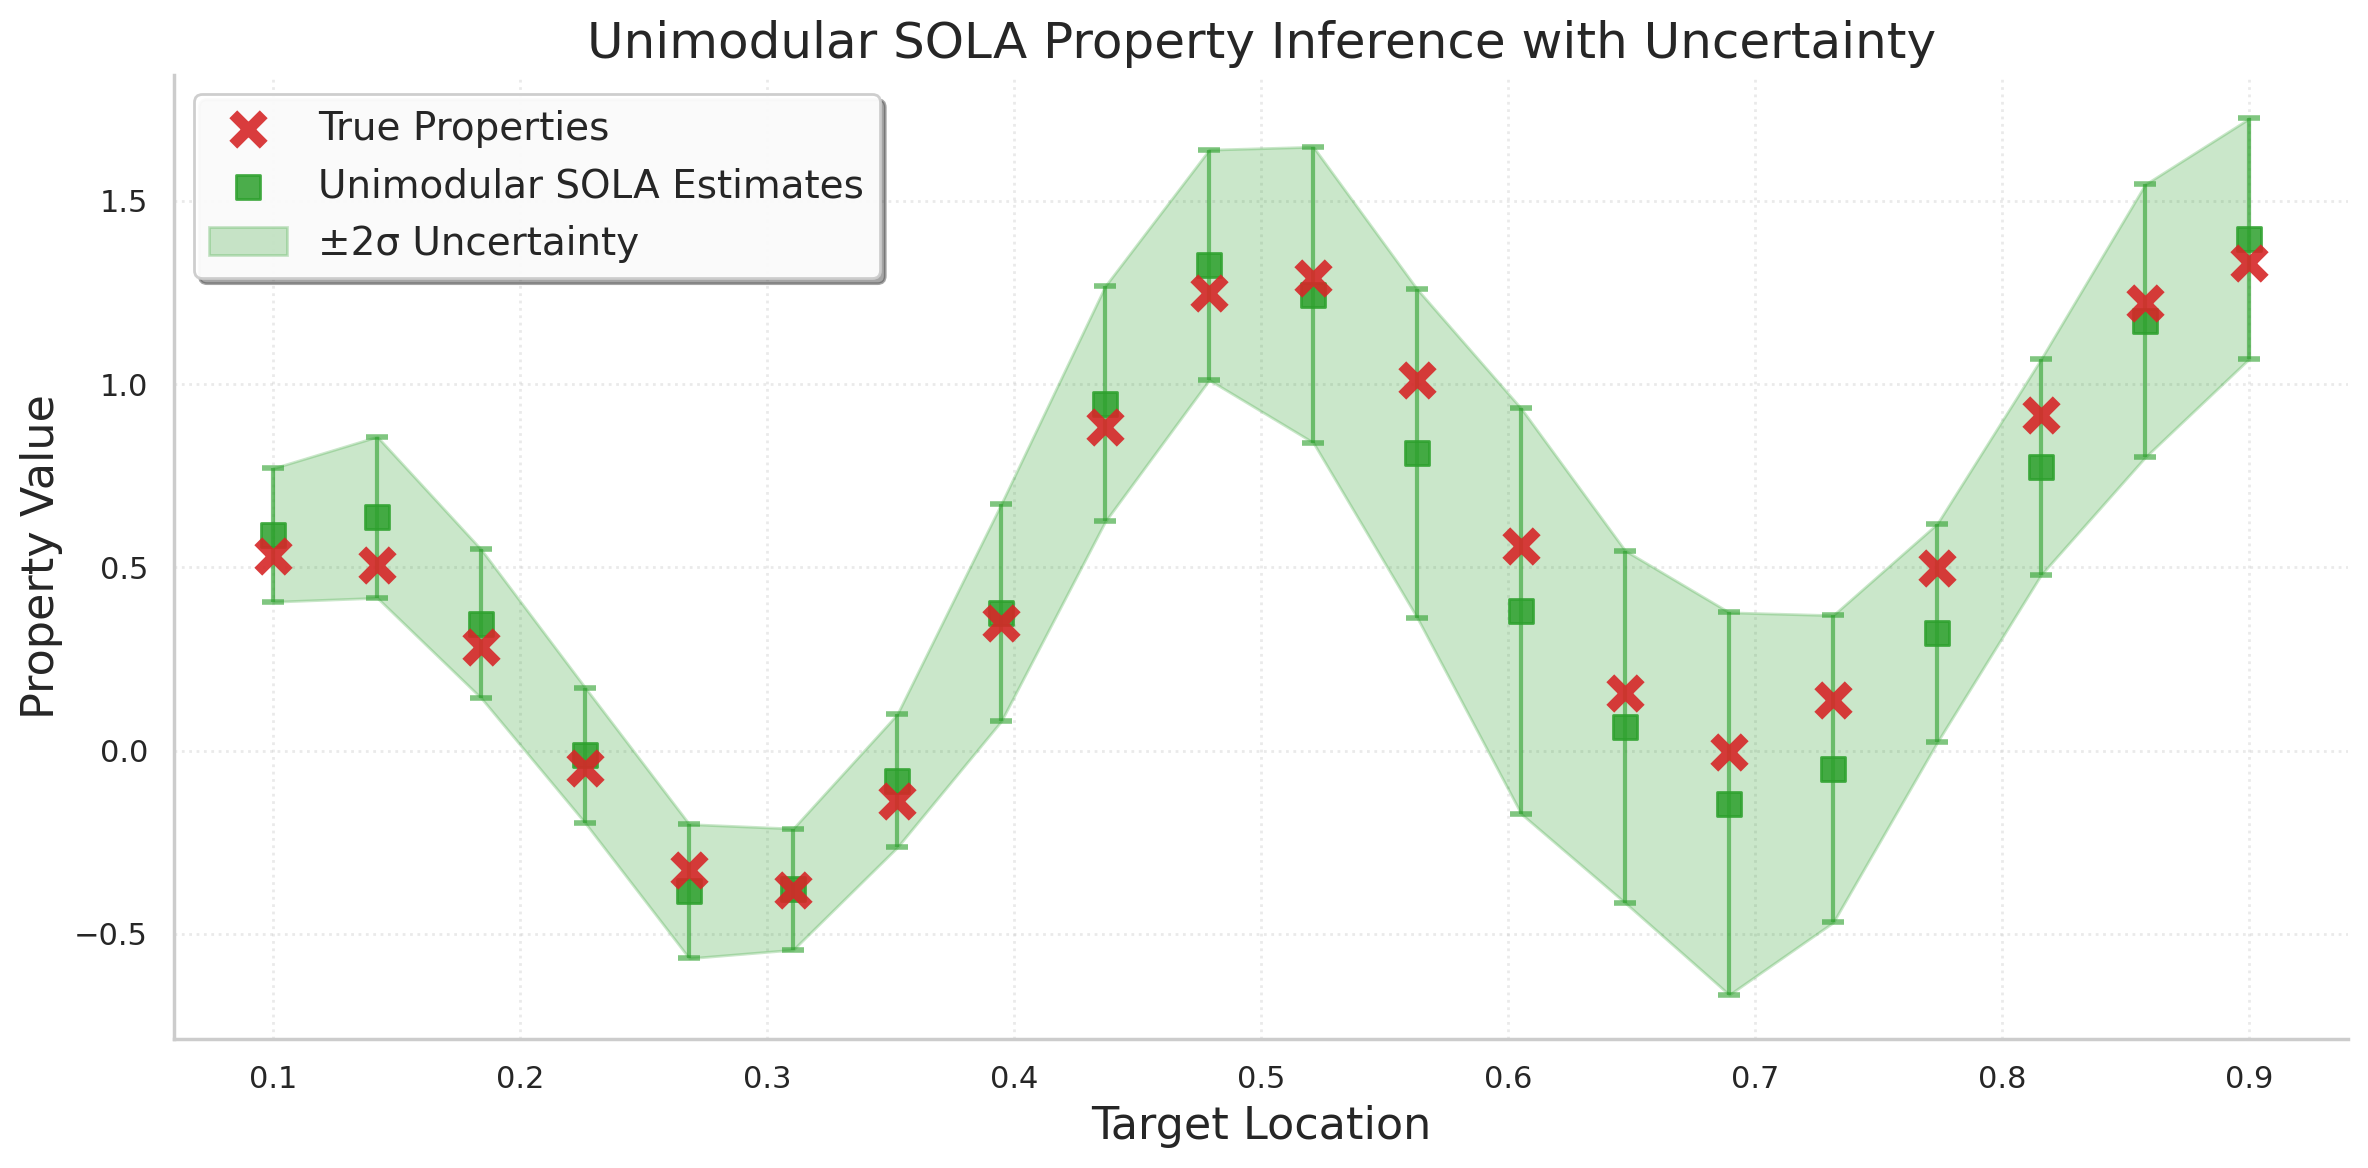


UNIMODULAR PROPERTY INFERENCE SUMMARY
Properties within ±2σ: 20/20 (100.0%)
Mean absolute error: 0.0924
RMS error: 0.1090
Max error: 0.1993
Average uncertainty (2σ): 0.3185


In [5]:
M_one = Function(M, evaluate_callable=lambda x: np.ones_like(x))
v = G(M_one)
w = np.ones(N_p)
u = W_inv(v)
beta = D.inner_product(v, u)
correction = LinearOperator.from_matrix(D, P, np.outer((X(v) - w) / beta, u))
X_unimodular = X - correction

print(f'Unimodularity check before correction: {X(v)[:5]}')
print(f'Unimodularity check after correction: {X_unimodular(v)[:5]}')

property_measure_unimodular = gaussian_D.affine_mapping(operator=X_unimodular)
p_bar = T(m_bar)

p_mean = property_measure_unimodular.expectation
P_cov_mat = property_measure_unimodular.covariance.matrix(dense=True, parallel=True, n_jobs=8)
p_std = np.sqrt(np.diag(P_cov_mat))

fig_title = 'Unimodular Property Inference Results'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 6), dpi=200)
plt.scatter(
    centers, p_bar, label='True Properties',
    color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10,
 )
plt.scatter(
    centers, p_mean, label='Unimodular SOLA Estimates',
    color='tab:green', marker='s', s=80, alpha=0.85, zorder=5,
 )
plt.fill_between(
    centers, p_mean - 2 * p_std, p_mean + 2 * p_std,
    alpha=0.25, color='tab:green', label='±2σ Uncertainty', zorder=1,
 )
plt.errorbar(
    centers, p_mean, yerr=2 * p_std, fmt='none',
    ecolor='tab:green', alpha=0.6, capsize=4, capthick=2, zorder=3,
 )
plt.title('Unimodular SOLA Property Inference with Uncertainty', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

property_errors = np.abs(p_mean - p_bar)
within_2sigma = np.sum(property_errors <= 2 * p_std)
print('\n' + '=' * 50)
print('UNIMODULAR PROPERTY INFERENCE SUMMARY')
print('=' * 50)
print(f'Properties within ±2σ: {within_2sigma}/{len(p_bar)} ({100 * within_2sigma / len(p_bar):.1f}%)')
print(f'Mean absolute error: {np.mean(property_errors):.4f}')
print(f'RMS error: {np.sqrt(np.mean(property_errors**2)):.4f}')
print(f'Max error: {np.max(property_errors):.4f}')
print(f'Average uncertainty (2σ): {np.mean(2 * p_std):.4f}')
print('=' * 50)

## Resolving Kernels

For the unimodular operator, the resolving kernels are the kernels of the approximate map $\mathcal{A}_{\mathrm{uni}} = X_{\mathrm{uni}} G$. We visualize all resolving kernels and color them by their relative misfit to the corresponding target kernels.

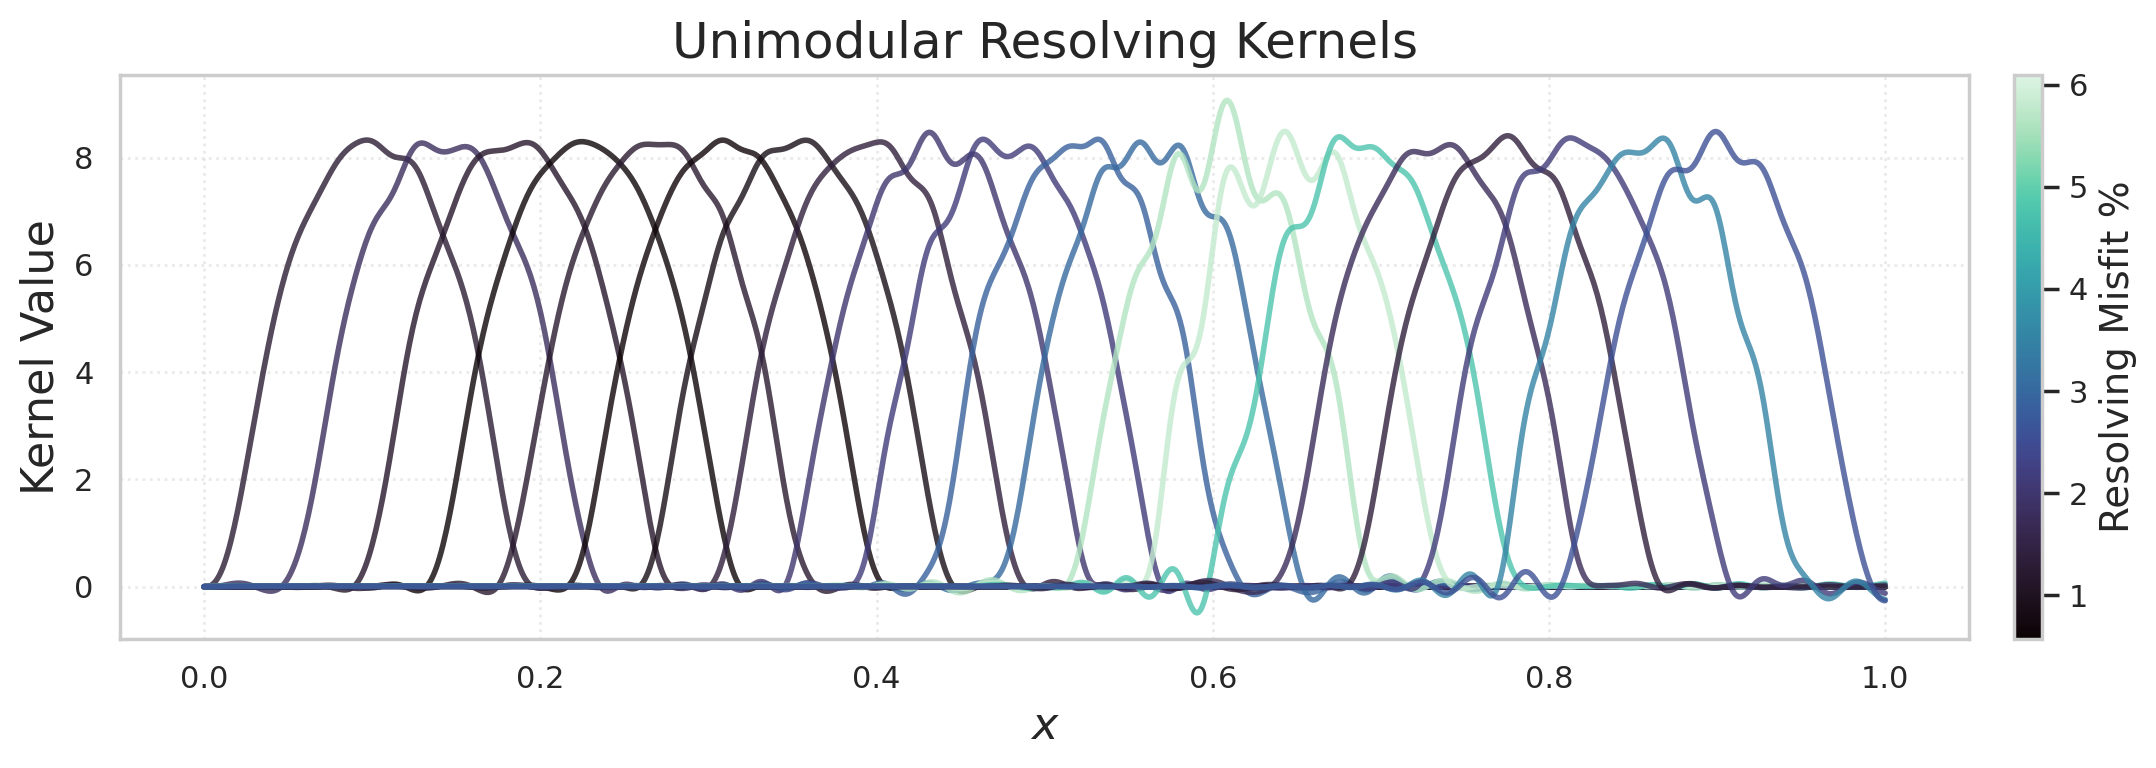

In [6]:
from matplotlib import cm

A_adjoint = (X_unimodular @ G).adjoint
cp = np.zeros(N_p)
resolving_misfits = np.zeros(N_p)

for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    target_kernel = T.get_kernel(i)
    resolving_misfits[i] = M.norm(A_i - target_kernel) / M.norm(target_kernel)
    cp[i] = 0

resolving_misfits_percent = 100 * resolving_misfits
vmin = resolving_misfits_percent.min() * 0.95
vmax = resolving_misfits_percent.max() * 1.05
norm = plt.Normalize(vmin, vmax)
cmap = plt.colormaps.get_cmap('mako')

fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
ax.set_title('Unimodular Resolving Kernels', fontsize=18)
ax.set_xlabel(r'$x$', fontsize=16)
ax.set_ylabel('Kernel Value', fontsize=16)

for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    color = cmap(norm(resolving_misfits_percent[i]))
    ax.plot(x, A_i.evaluate(x), alpha=0.8, linewidth=2, color=color)
    cp[i] = 0

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Resolving Misfit %', fontsize=14)

ax.grid(True, linestyle=':', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(figures_folder, 'unimodular_resolving_kernels.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(figures_folder, 'unimodular_resolving_kernels.pdf'), bbox_inches='tight')
plt.show()

## 20-Cell Physical Boxcar Discretization

We now keep the same observed data $\tilde d$ and discretize only the model side using 20 **physical cell indicators** on $[0,1]$ rather than orthonormalized boxcars.
This matches the representation expected by `sola-base`: the discrete unknowns are cell values, while the model inner product is encoded separately through a mass matrix.

If $I_j$ is the $j$-th cell, the basis functions are

$$
\phi_j(x) = \mathbf{1}_{I_j}(x), \qquad j=1,\dots,20,
$$

and the exact $L^2$ Gram matrix is diagonal:

$$
[M_{\mathrm{disc}}]_{jj} = |I_j|.
$$

We therefore keep two complementary objects:

- a basis-backed `Lebesgue` space for projections and piecewise-constant reconstructions,
- a `MassWeightedHilbertSpace` on coefficient vectors so that adjoints of $G$ and $T$ are correct in the discrete $L^2$ geometry.

The dense operator matrices are the physical cell-basis representations

$$
[G_{\mathrm{disc}}]_{ij} = \int_{I_j} K_i(x)\,dx,
\qquad
[T_{\mathrm{disc}}]_{kj} = \int_{I_j} T^{(k)}(x)\,dx,
$$

and `LinearOperator.from_formal_adjoint` lifts them to operators with the correct mass-weighted adjoints.

Discrete model dimension: 20
G_disc matrix shape: (100, 20)
T_disc matrix shape: (20, 20)
Cell width: 0.050
Max |Gram - mass| for cell basis: 6.17e-04


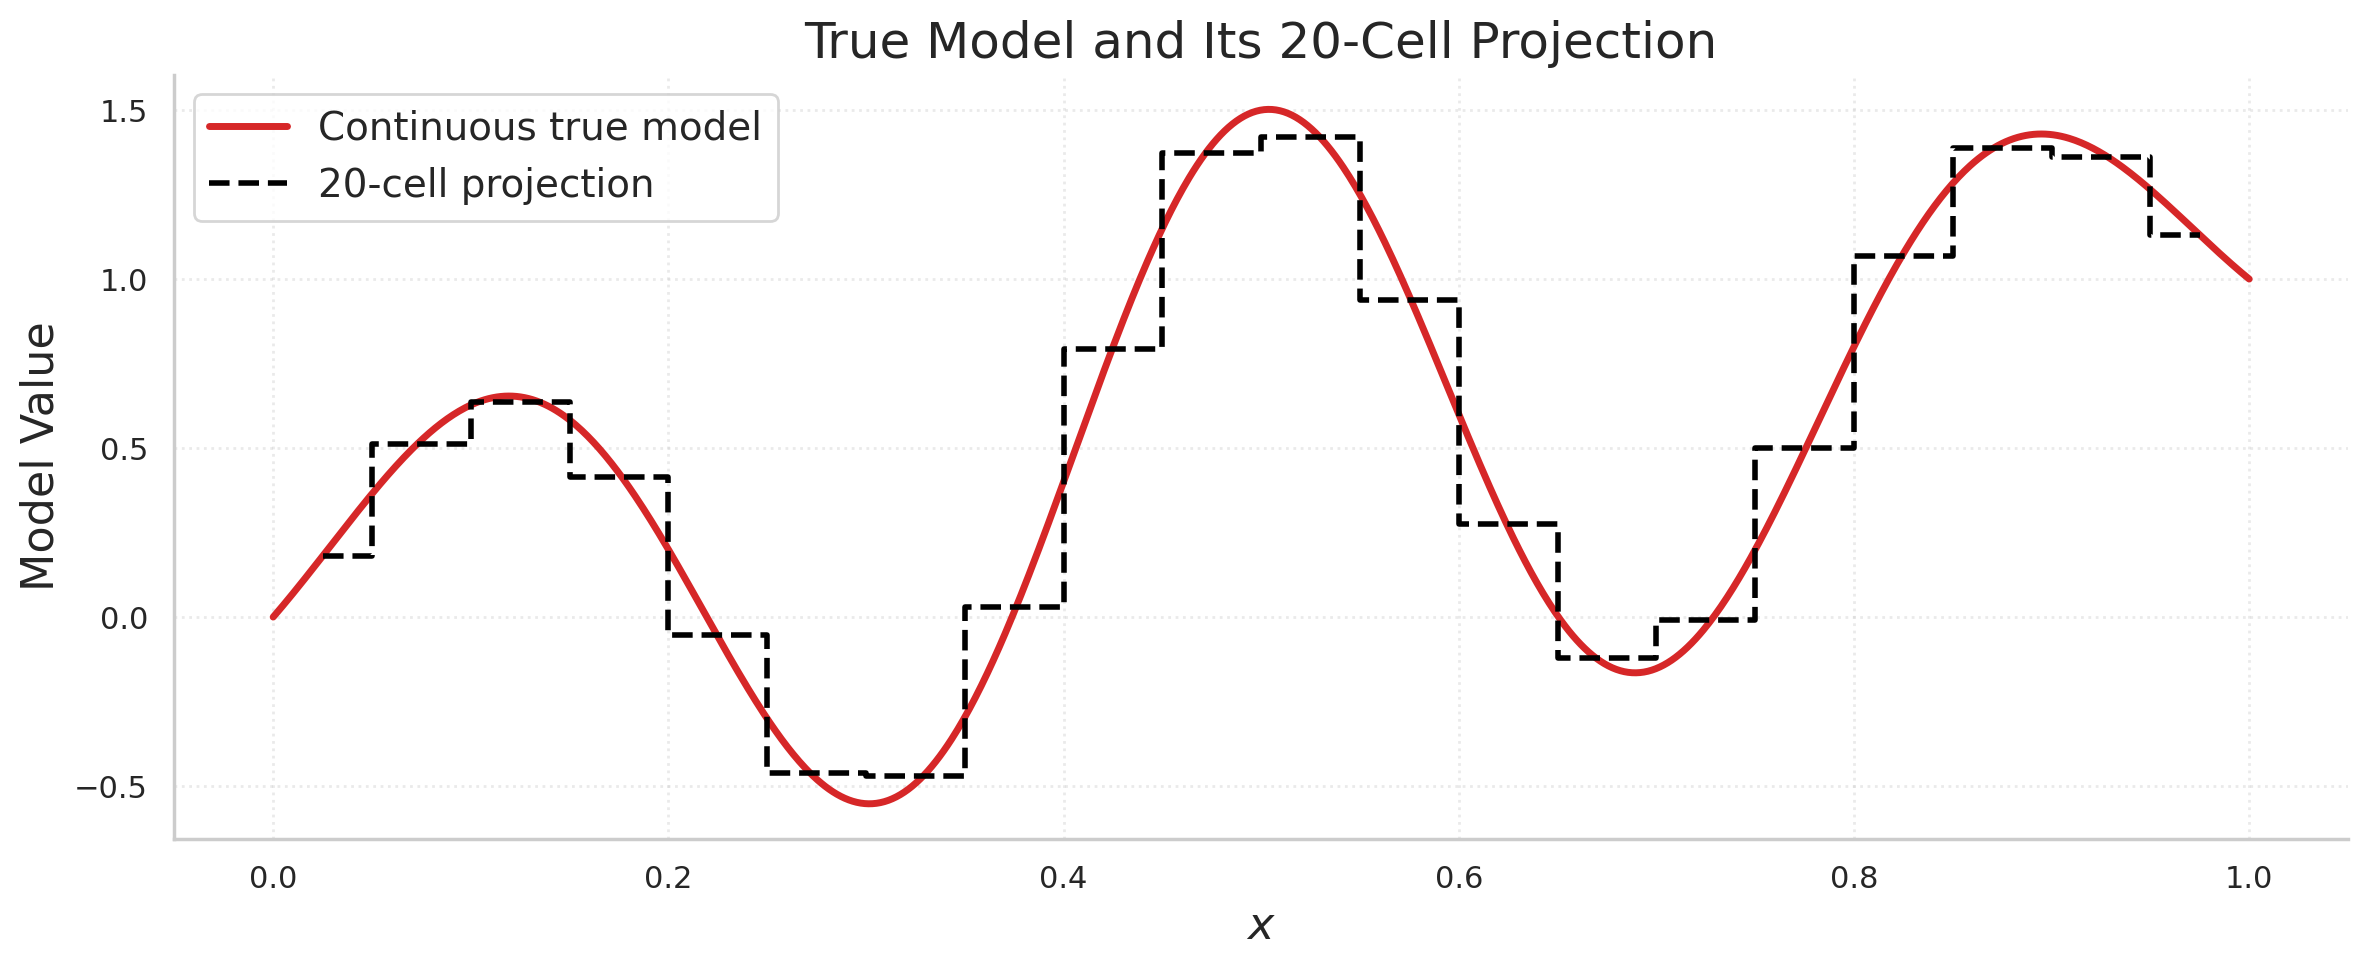

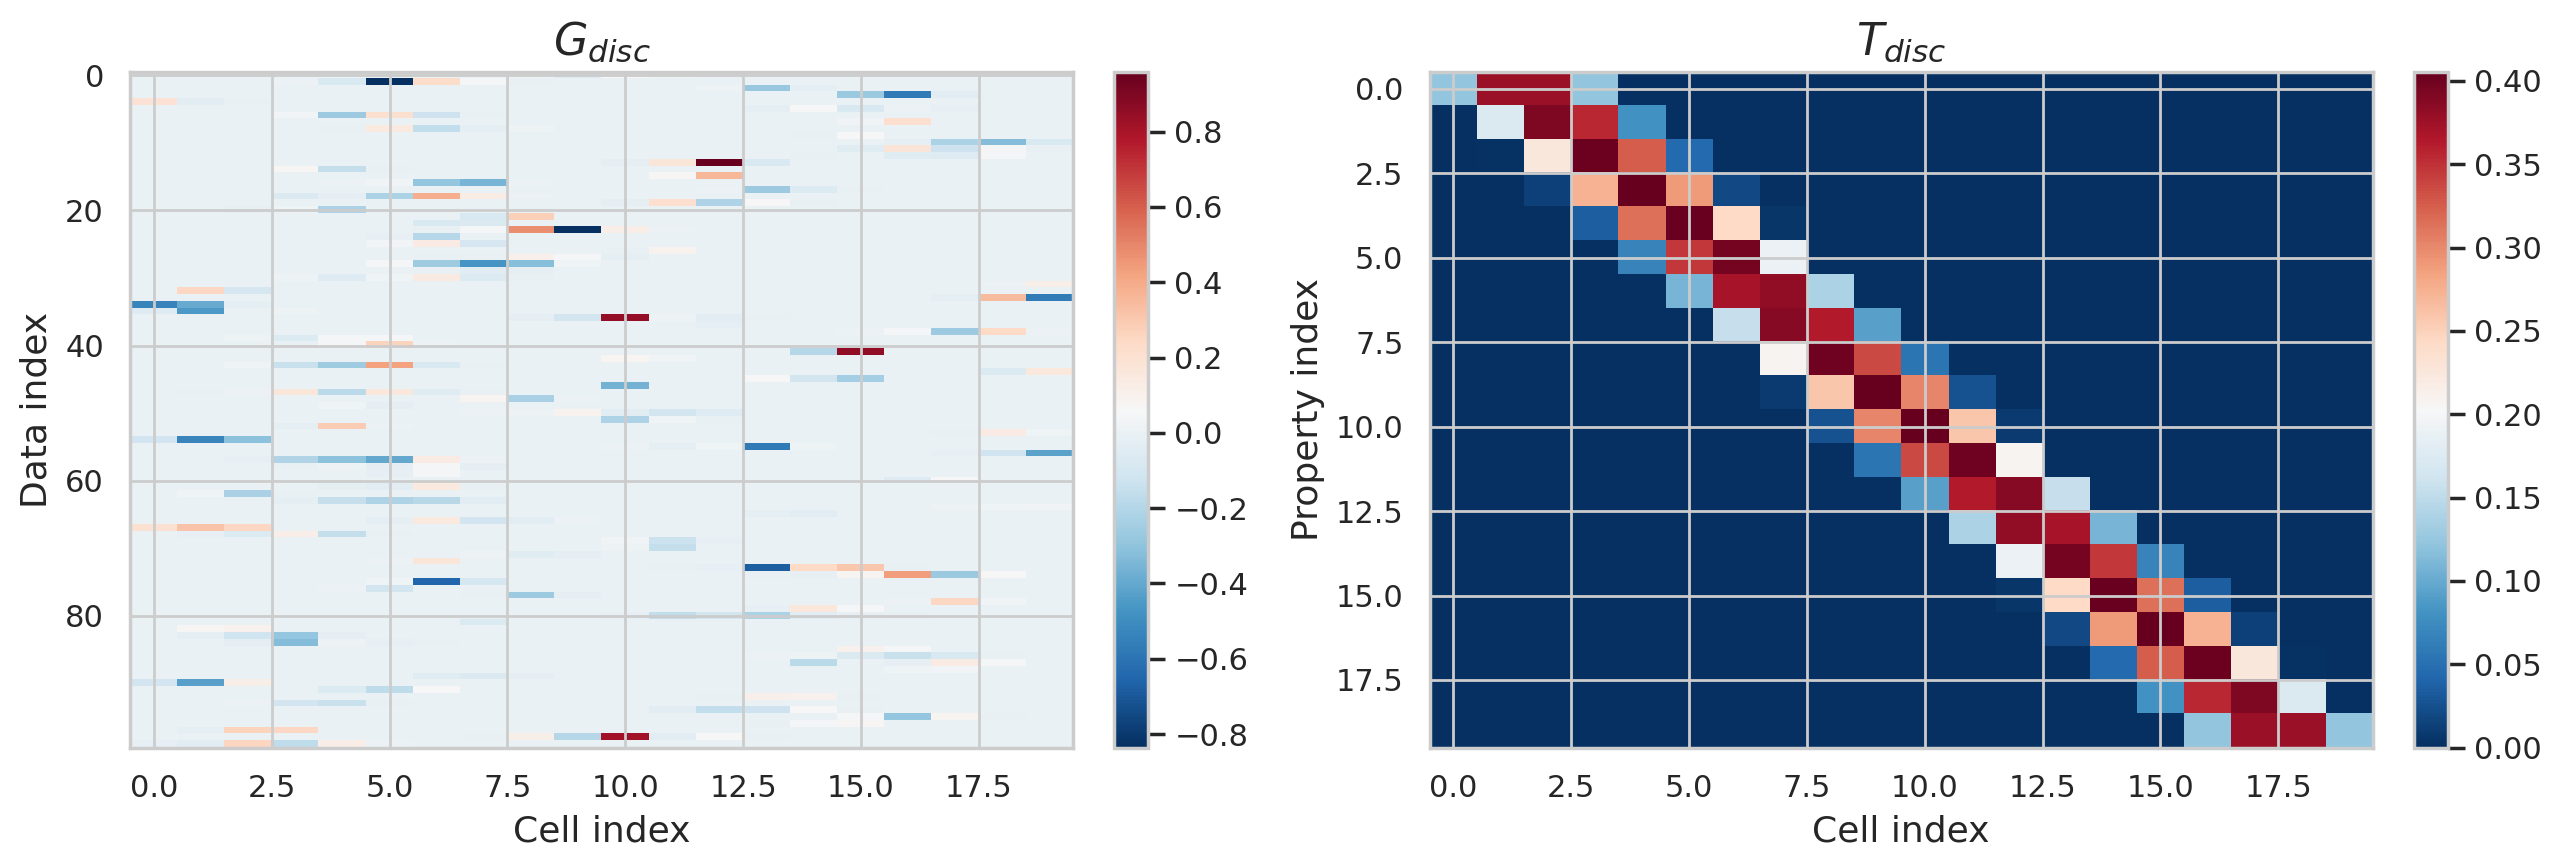

In [7]:
N_box = 20
box_edges = np.linspace(function_domain.a, function_domain.b, N_box + 1)
box_centers = 0.5 * (box_edges[:-1] + box_edges[1:])
cell_widths = np.diff(box_edges)
box_width = cell_widths[0]

M_disc_functions = Lebesgue(N_box, function_domain, basis='none')
boxcar_function_provider = BoxCarFunctionProvider(
    M_disc_functions,
    default_width=box_width,
    centers=box_centers,
    normalize=False,
    default_height=1.0,
 )
M_disc_functions.set_basis_provider(
    CustomBasisProvider(
        M_disc_functions,
        boxcar_function_provider,
        orthonormal=False,
        basis_type='cell-boxcar',
    )
)

E_disc = EuclideanSpace(N_box)
mass_matrix = np.diag(cell_widths)
mass_operator = LinearOperator.self_adjoint_from_matrix(E_disc, mass_matrix)
inverse_mass_operator = LinearOperator.self_adjoint_from_matrix(
    E_disc,
    np.diag(1.0 / cell_widths),
)
M_disc = MassWeightedHilbertSpace(E_disc, mass_operator, inverse_mass_operator)

G_cell = SOLAOperator(
    M_disc_functions,
    D,
    kernels=[G.get_kernel(i) for i in range(N_d)],
    integration_config=G.integration,
 )
T_cell = SOLAOperator(
    M_disc_functions,
    P,
    kernels=[T.get_kernel(k) for k in range(N_p)],
    integration_config=T.integration,
 )

G_disc_mat = G_cell.matrix(dense=True, parallel=True, n_jobs=8)
T_disc_mat = T_cell.matrix(dense=True, parallel=True, n_jobs=8)

G_disc_base = LinearOperator.from_matrix(E_disc, D, G_disc_mat)
T_disc_base = LinearOperator.from_matrix(E_disc, P, T_disc_mat)
G_disc = LinearOperator.from_formal_adjoint(M_disc, D, G_disc_base)
T_disc = LinearOperator.from_formal_adjoint(M_disc, P, T_disc_base)

m_bar_disc_coeffs = M_disc_functions.to_components(m_bar)
m_bar_disc = M_disc_functions.from_components(m_bar_disc_coeffs)
m_bar_disc_levels = m_bar_disc.evaluate(box_centers)

print(f'Discrete model dimension: {N_box}')
print(f'G_disc matrix shape: {G_disc_mat.shape}')
print(f'T_disc matrix shape: {T_disc_mat.shape}')
print(f'Cell width: {box_width:.3f}')
print(f'Max |Gram - mass| for cell basis: {np.max(np.abs(M_disc_functions.metric - mass_matrix)):.2e}')

fig_title = 'True Model Continuous vs Discretized'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label='Continuous true model')
plt.step(
    box_centers,
    m_bar_disc_levels,
    where='mid',
    color='black',
    linewidth=2.0,
    linestyle='--',
    label='20-cell projection',
 )
plt.title('True Model and Its 20-Cell Projection', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

fig_title = 'Discrete Operator Matrices'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=200)
im0 = axes[0].imshow(G_disc_mat, aspect='auto', cmap='RdBu_r')
axes[0].set_title(r'$G_{disc}$', fontsize=16)
axes[0].set_xlabel('Cell index', fontsize=13)
axes[0].set_ylabel('Data index', fontsize=13)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(T_disc_mat, aspect='auto', cmap='RdBu_r')
axes[1].set_title(r'$T_{disc}$', fontsize=16)
axes[1].set_xlabel('Cell index', fontsize=13)
axes[1].set_ylabel('Property index', fontsize=13)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(filename, dpi=300, bbox_inches='tight')
fig.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

Discrete unimodularity check: [1. 1. 1. 1. 1.]
Mean |continuous - discrete| on properties: 3.2393e-02
Max |continuous - discrete| on properties: 1.0458e-01


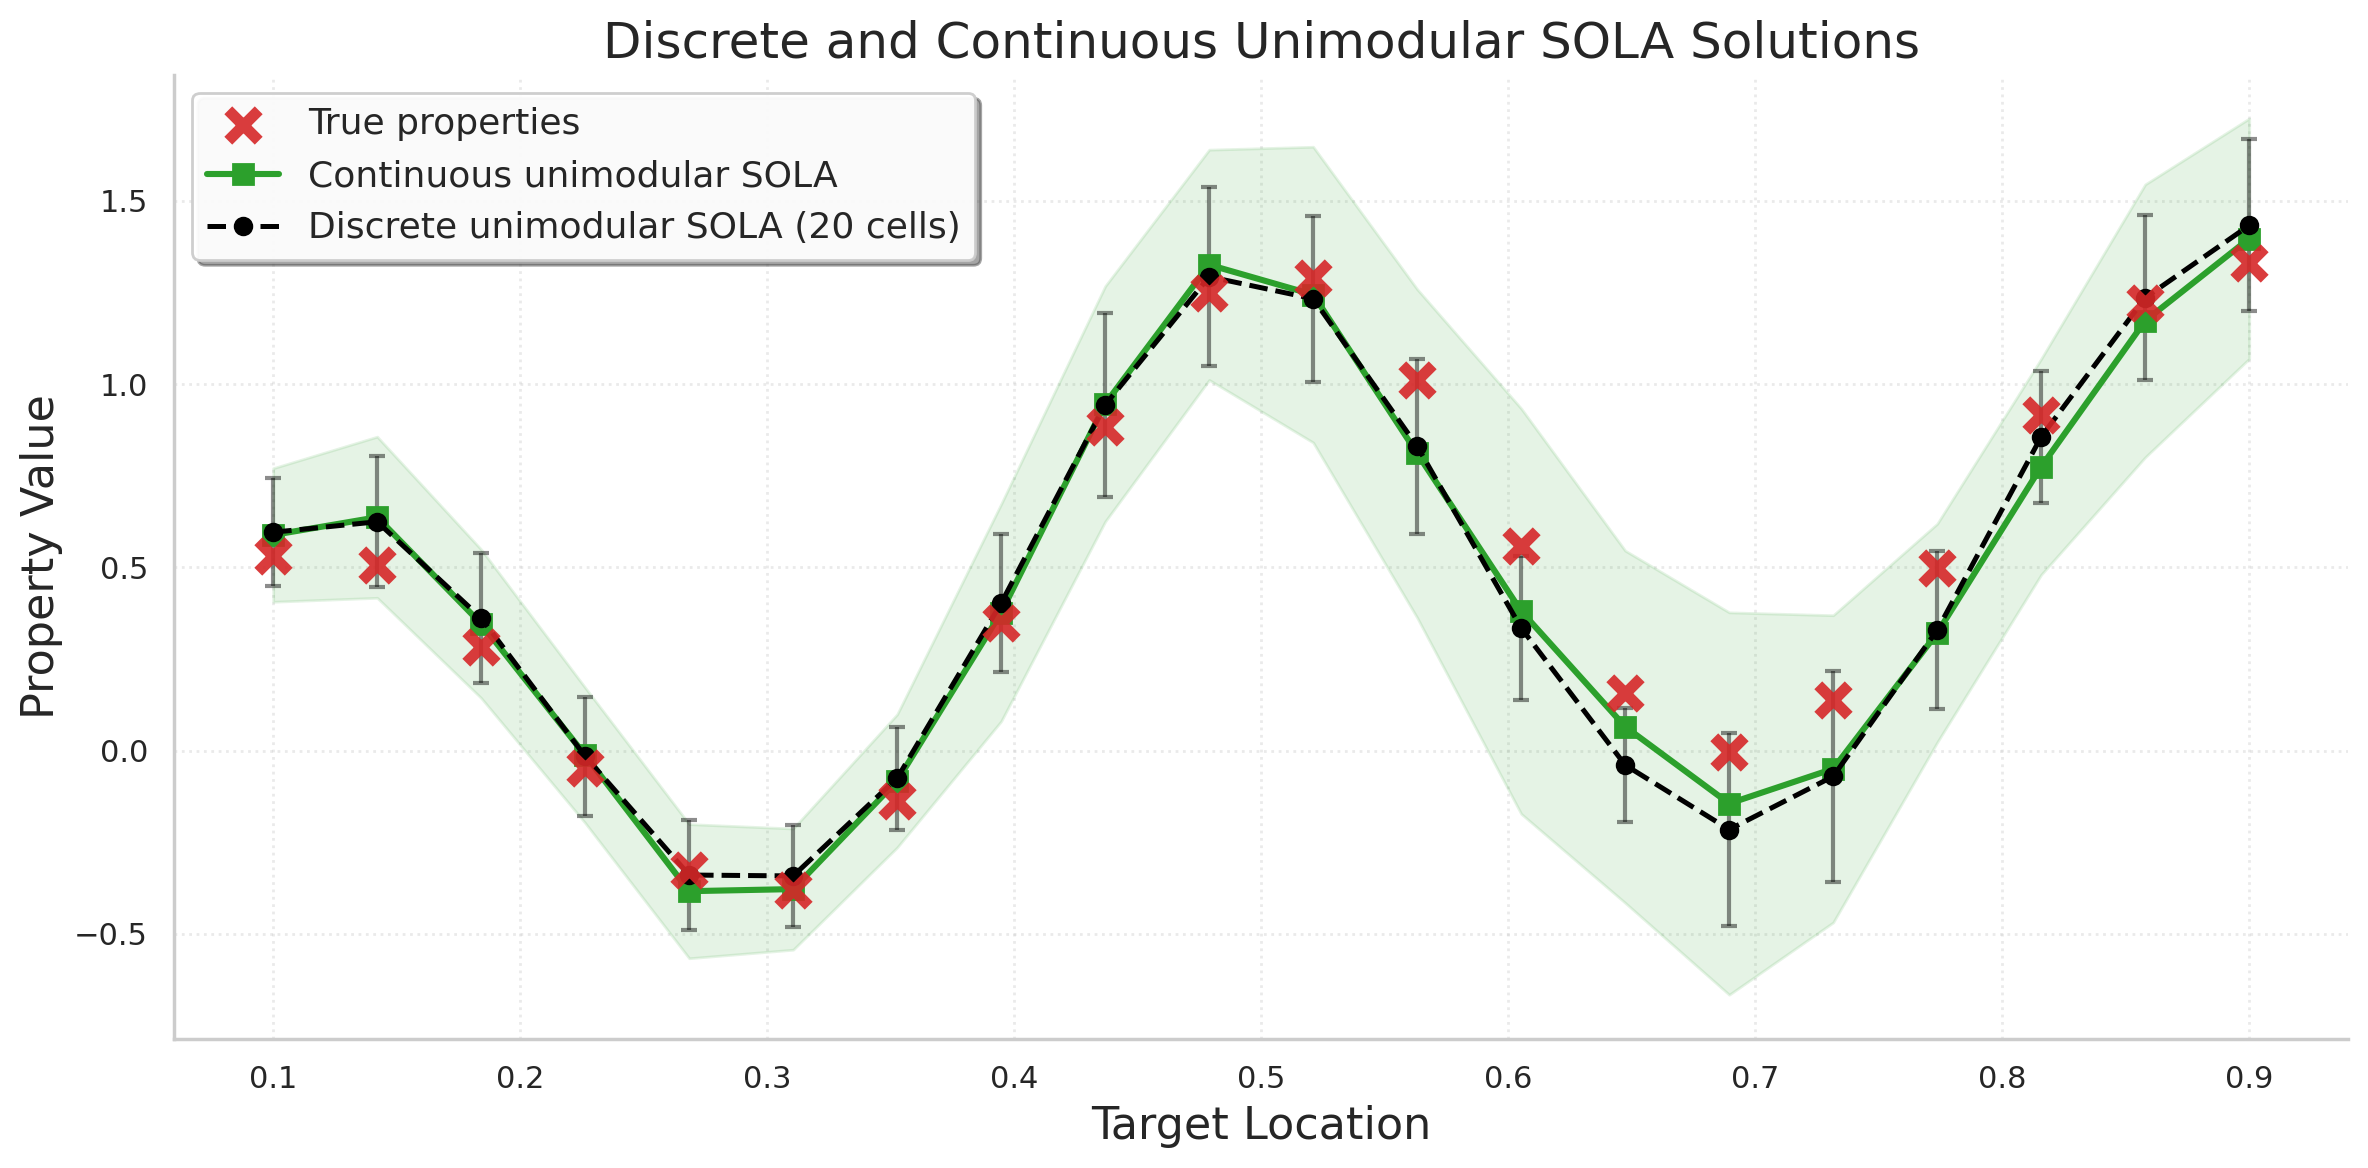

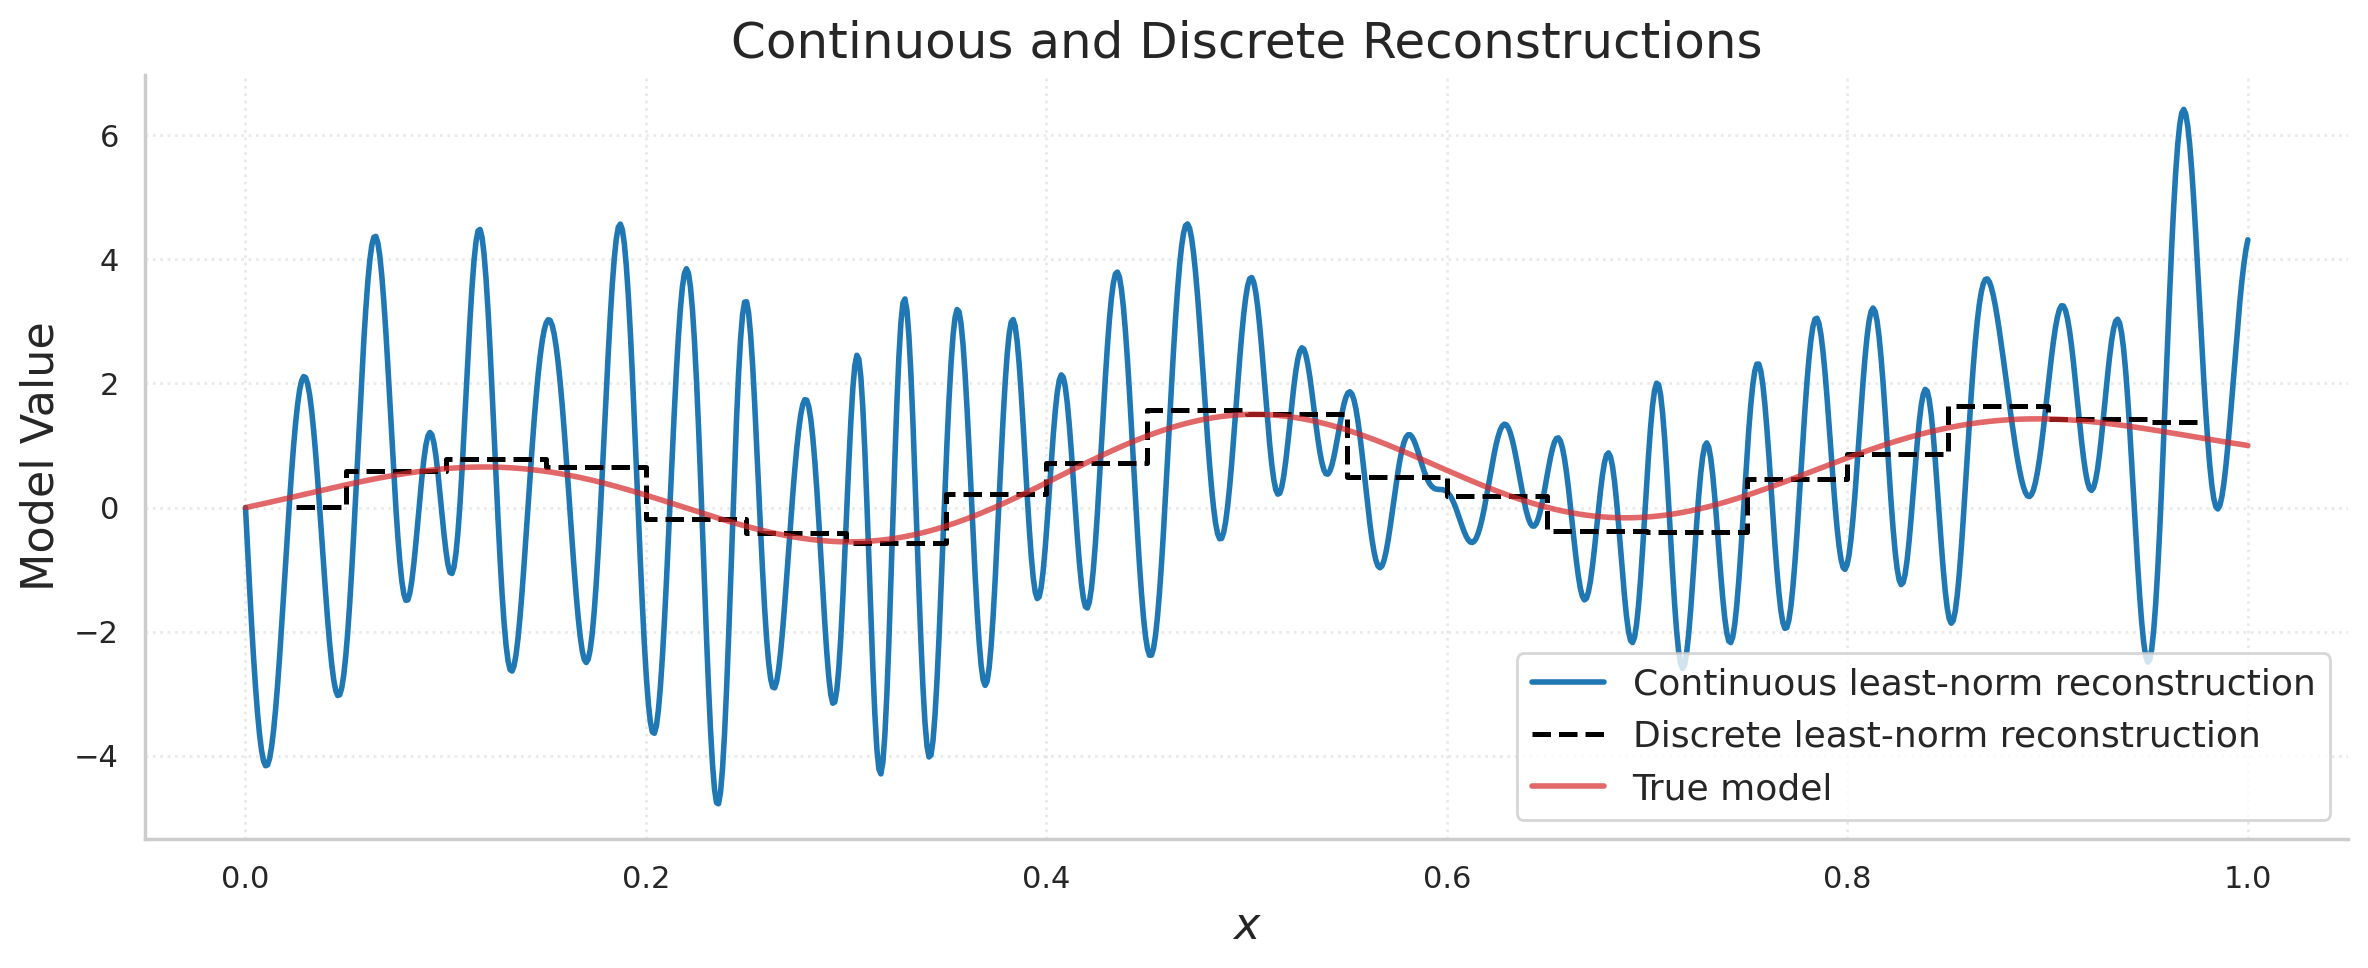

In [8]:
Lambda_disc = G_disc @ G_disc.adjoint
W_disc = cholesky_solver(Lambda_disc + gaussian_D.covariance)
G_disc_inv = G_disc.adjoint @ W_disc
X_disc = T_disc @ G_disc_inv

m_one_disc = M_disc_functions.to_components(M_one)
v_disc = G_disc(m_one_disc)
u_disc = W_disc(v_disc)
beta_disc = D.inner_product(v_disc, u_disc)
w_disc = np.ones(N_p)
correction_disc = LinearOperator.from_matrix(
    D,
    P,
    np.outer((X_disc(v_disc) - w_disc) / beta_disc, u_disc),
 )
X_disc_unimodular = X_disc - correction_disc

property_measure_disc_unimodular = gaussian_D.affine_mapping(operator=X_disc_unimodular)
p_mean_disc = property_measure_disc_unimodular.expectation
P_cov_disc = property_measure_disc_unimodular.covariance.matrix(dense=True, parallel=True, n_jobs=8)
p_std_disc = np.sqrt(np.diag(P_cov_disc))
m_tilde_disc = G_disc_inv(d_tilde)
m_tilde_disc_levels = M_disc_functions.from_components(m_tilde_disc).evaluate(box_centers)

print(f'Discrete unimodularity check: {X_disc_unimodular(v_disc)[:5]}')
print(f'Mean |continuous - discrete| on properties: {np.mean(np.abs(p_mean - p_mean_disc)):.4e}')
print(f'Max |continuous - discrete| on properties: {np.max(np.abs(p_mean - p_mean_disc)):.4e}')

fig_title = 'Discrete vs Continuous Unimodular SOLA Properties'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 6), dpi=200)
plt.scatter(
    centers, p_bar, label='True properties',
    color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10,
 )
plt.plot(
    centers, p_mean,
    color='tab:green', marker='s', linewidth=2.2, markersize=7,
    label='Continuous unimodular SOLA', zorder=6,
 )
plt.plot(
    centers, p_mean_disc,
    color='black', marker='o', linestyle='--', linewidth=1.8, markersize=6,
    label='Discrete unimodular SOLA (20 cells)', zorder=7,
 )
plt.fill_between(
    centers, p_mean - 2 * p_std, p_mean + 2 * p_std,
    alpha=0.12, color='tab:green', zorder=1,
 )
plt.errorbar(
    centers, p_mean_disc, yerr=2 * p_std_disc, fmt='none',
    ecolor='black', alpha=0.45, capsize=3, capthick=1.5, zorder=5,
 )
plt.title('Discrete and Continuous Unimodular SOLA Solutions', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

fig_title = 'Continuous vs Discrete Reconstructions'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_tilde.evaluate(x), color='tab:blue', linewidth=2.0, label='Continuous least-norm reconstruction')
plt.step(
    box_centers,
    m_tilde_disc_levels,
    where='mid',
    color='black',
    linewidth=1.8,
    linestyle='--',
    label='Discrete least-norm reconstruction',
 )
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.0, alpha=0.7, label='True model')
plt.title('Continuous and Discrete Reconstructions', fontsize=18)
plt.xlabel(r'$x$', fontsize=16)
plt.ylabel('Model Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Export To sola-base And Compare Outputs

We now export the **same discrete problem** to `sola-base`, run its preprocessing and LSQR pipeline, and compare its outputs against the notebook’s discrete `intervalinf` and `pygeoinf` solution.

Because the notebook now uses the same physical cell basis as `sola-base`, the exported matrices and targets can be written directly in the `sola-base` file formats without any additional basis transform.

In [9]:
from pathlib import Path
import shutil
import subprocess
import sys

workspace_root = Path('/home/adrian/PhD/Inferences')
sola_base_dir = workspace_root / 'sola-base'
sola_input_dir = sola_base_dir / 'sola_inputs_intervalinf_demo'
sola_output_dir = sola_base_dir / 'sola_outputs_intervalinf_demo'
targets_dir = sola_input_dir / 'T'

for path in (sola_input_dir, sola_output_dir):
    if path.exists():
        shutil.rmtree(path)
targets_dir.mkdir(parents=True, exist_ok=True)
(sola_output_dir / 'A').mkdir(parents=True, exist_ok=True)

def write_dense_vector(path, values):
    np.savetxt(path, np.asarray(values, dtype=float))

def write_sparse_matrix_ijv(path, matrix, tol=1e-14):
    matrix = np.asarray(matrix, dtype=float)
    rows, cols = np.where(np.abs(matrix) > tol)
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(f'{len(rows)}\n')
        handle.write(f'{matrix.shape[0]} {matrix.shape[1]}\n')
        for i, j in zip(rows, cols):
            handle.write(f'{i} {j} {matrix[i, j]:.16e}\n')

def write_sparse_vector_jv(path, vector, tol=1e-14):
    vector = np.asarray(vector, dtype=float)
    nz = np.where(np.abs(vector) > tol)[0]
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(f'{len(vector)}\n')
        for j in nz:
            handle.write(f'{j} {vector[j]:.16e}\n')

V_sola = cell_widths.copy()
dstd_sola = np.sqrt(np.diag(C_D_matrix))
T_sola = T_disc_mat / V_sola[None, :]
ks_to_solve = np.arange(N_p, dtype=int)
eta_sola = 1.0
eta_str = str(eta_sola).replace('.', 'p')

write_sparse_matrix_ijv(sola_input_dir / 'G', G_disc_mat)
write_dense_vector(sola_input_dir / 'd', d_tilde)
write_dense_vector(sola_input_dir / 'dstd', dstd_sola)
write_dense_vector(sola_input_dir / 'V', V_sola)

for k in ks_to_solve:
    write_sparse_vector_jv(targets_dir / f'T_{k}', T_sola[k])

np.savetxt(sola_input_dir / 'ks_to_solve', ks_to_solve, fmt='%d')

parameters_cfg = '\n'.join([
    '[inversion]',
    f'eta = {eta_sola}',
    'iters = 500',
    'dumpiter = 100',
    '',
    '[folders]',
    f'input = {sola_input_dir.name}',
    f'output = {sola_output_dir.name}',
]) + '\n'
(sola_base_dir / 'parameters.cfg').write_text(parameters_cfg, encoding='utf-8')

compile_result = subprocess.run(
    ['bash', 'compile.sh'],
    cwd=sola_base_dir / 'LSQR_SOLA_paral',
    check=True,
    capture_output=True,
    text=True,
 )
if compile_result.stdout.strip():
    print(compile_result.stdout)
if compile_result.stderr.strip():
    print(compile_result.stderr)

env = os.environ.copy()
env.setdefault('OMP_NUM_THREADS', '4')
ks_rel_path = f'{sola_input_dir.name}/ks_to_solve'
for command in (
    [sys.executable, 'sola_preproc.py'],
    [sys.executable, 'sola_lsqr.py', ks_rel_path],
    [sys.executable, 'sola_postproc.py'],
    [sys.executable, 'sola_ak.py', ks_rel_path],
):
    result = subprocess.run(
        command,
        cwd=sola_base_dir,
        check=True,
        capture_output=True,
        text=True,
        env=env,
    )
    print(' '.join(command))
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)

print(f'Exported sola-base inputs to: {sola_input_dir}')
print(f'sola-base outputs written to: {sola_output_dir}')
print(f'eta used for sola-base run: {eta_sola:.6f}')

/home/adrian/miniconda3/envs/inferences3/bin/python sola_preproc.py
/home/adrian/PhD/Inferences/sola-base/sola_preproc.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  G = pd.read_table( os.path.join(input_folder, 'G'), delim_whitespace=True, skiprows=2, header=None, names=['i','j','val'])

/home/adrian/miniconda3/envs/inferences3/bin/python sola_lsqr.py sola_inputs_intervalinf_demo/ks_to_solve
./LSQR_SOLA_paral/LSQR_inversion_for_SOLA_N_paral sola_inputs_intervalinf_demo/Q_sparse0_norm_1p0 sola_inputs_intervalinf_demo/T/T sola_inputs_intervalinf_demo/ks_to_solve sola_outputs_intervalinf_demo/SOLUTION_1p0/SOLUTION 500 1.000000 sola_inputs_intervalinf_demo/c_sparse0_norm sola_inputs_intervalinf_demo/G_sparse0_norm_firstraw sola_inputs_intervalinf_demo/V 0 100
reading sparse matrix from 'sola_inputs_intervalinf_demo/Q_sparse0_norm_1p0' ... 
(21x99)-(1150) 
Reorganisation liste des colo

SOLA-BASE VS NOTEBOOK COMPARISON
Max |property mean difference|: 3.7322e-02
Max |property std difference|: 9.2533e-03
Mean notebook 2σ width: 2.0045e-01
Mean sola-base 2σ width: 1.9229e-01
Max |weight difference| in sola-base coordinates: 5.6294e-03
Max |integrated averaging-kernel difference|: 3.0858e-02


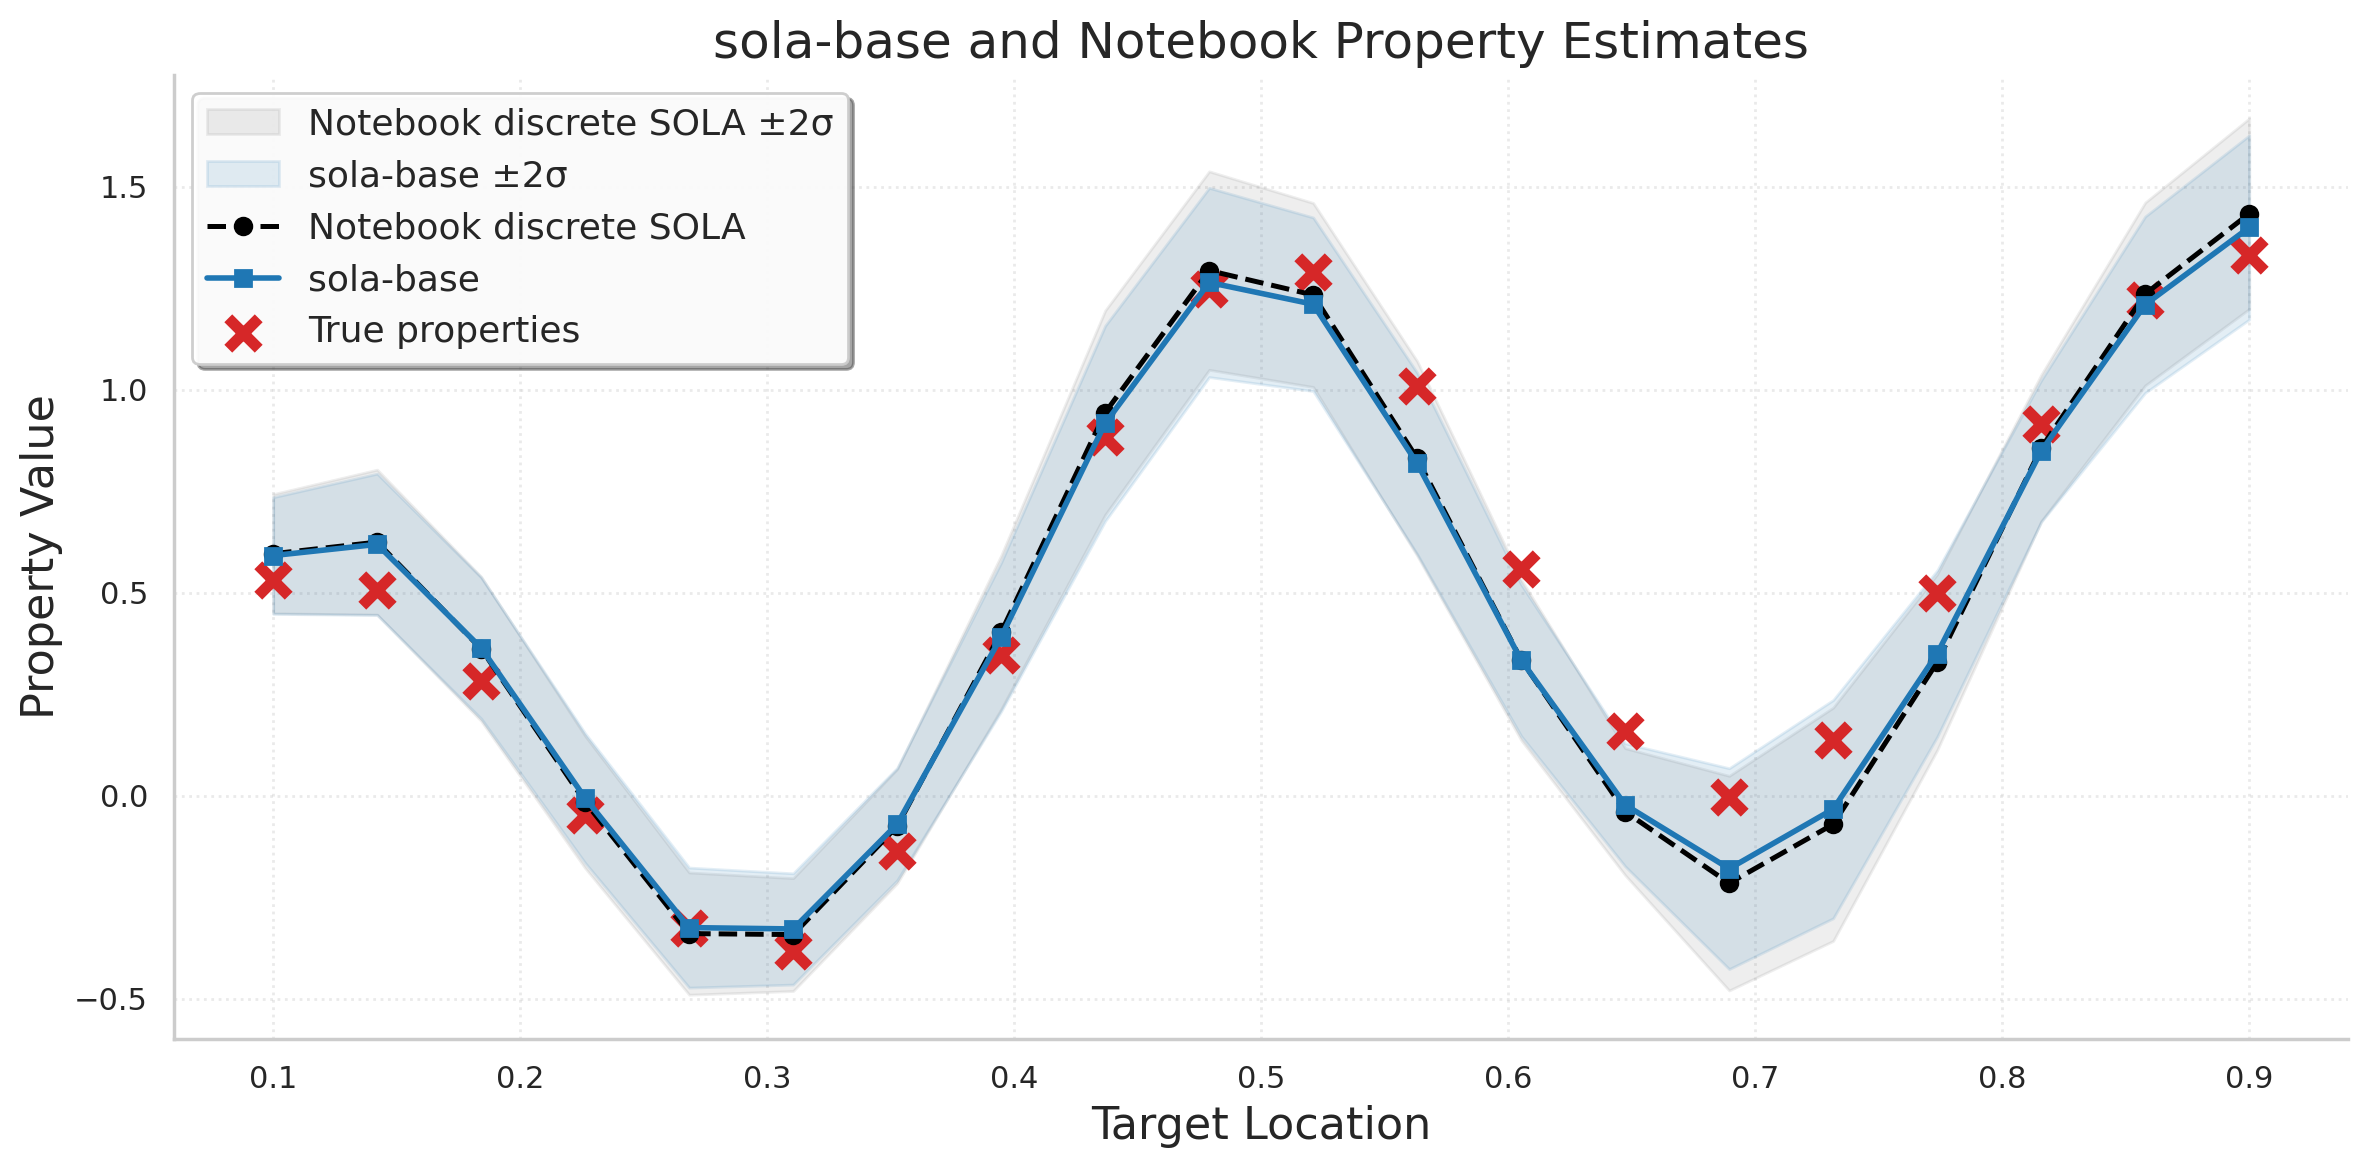

sola-base comparisons passed within the documented discrete round-trip tolerances.


In [10]:
sola_m = np.loadtxt(sola_output_dir / f'm_{eta_str}')
sola_mstd = np.loadtxt(sola_output_dir / f'mstd_{eta_str}')
sola_weights = np.vstack([
    np.loadtxt(sola_output_dir / f'SOLUTION_{eta_str}' / f'SOLUTION_{k}.txt')
    for k in ks_to_solve
])
sola_averaging_kernels = np.vstack([
    np.loadtxt(sola_output_dir / 'A' / f'A_{k}')
    for k in ks_to_solve
])

dstd_sola = np.loadtxt(sola_input_dir / 'dstd')
V_sola = np.loadtxt(sola_input_dir / 'V')
G_sparse = np.loadtxt(sola_input_dir / 'G_sparse0_norm', skiprows=2)
G_sparse_mat = np.zeros_like(G_disc_mat)
for i, j, value in G_sparse:
    G_sparse_mat[int(i), int(j)] = value

G_norm_expected = G_disc_mat / dstd_sola[:, None]
swap = []
for i in range(G_sparse_mat.shape[0]):
    diffs = np.max(np.abs(G_norm_expected - G_sparse_mat[i]), axis=1)
    swap.append(int(np.argmin(diffs)))
swap = np.asarray(swap)

X_disc_matrix = X_disc_unimodular.matrix(dense=True, parallel=True, n_jobs=8)
X_disc_swapped_norm = X_disc_matrix[:, swap] * dstd_sola[swap][None, :]
A_disc_from_sola_coords = X_disc_swapped_norm @ G_sparse_mat / V_sola[None, :]
A_disc_integrated = A_disc_from_sola_coords * V_sola[None, :]
sola_averaging_integrated = sola_averaging_kernels * V_sola[None, :]

property_diff = sola_m - p_mean_disc
uncertainty_diff = sola_mstd - p_std_disc
weight_diff = sola_weights - X_disc_swapped_norm
averaging_integrated_diff = sola_averaging_integrated - A_disc_integrated

print('SOLA-BASE VS NOTEBOOK COMPARISON')
print('=' * 50)
print(f'Max |property mean difference|: {np.max(np.abs(property_diff)):.4e}')
print(f'Max |property std difference|: {np.max(np.abs(uncertainty_diff)):.4e}')
print(f'Mean notebook 2σ width: {np.mean(2 * p_std_disc):.4e}')
print(f'Mean sola-base 2σ width: {np.mean(2 * sola_mstd):.4e}')
print(f'Max |weight difference| in sola-base coordinates: {np.max(np.abs(weight_diff)):.4e}')
print(f'Max |integrated averaging-kernel difference|: {np.max(np.abs(averaging_integrated_diff)):.4e}')
print('=' * 50)

fig_title = 'sola-base vs Notebook Property Estimates'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 6), dpi=200)
plt.fill_between(
    centers, p_mean_disc - 2 * p_std_disc, p_mean_disc + 2 * p_std_disc,
    alpha=0.10, color='0.35', label='Notebook discrete SOLA ±2σ',
)
plt.fill_between(
    centers, sola_m - 2 * sola_mstd, sola_m + 2 * sola_mstd,
    alpha=0.12, color='tab:blue', label='sola-base ±2σ',
)
plt.plot(
    centers, p_mean_disc,
    color='black', marker='o', linestyle='--', linewidth=1.8, markersize=6,
    label='Notebook discrete SOLA',
)
plt.plot(
    centers, sola_m,
    color='tab:blue', marker='s', linewidth=2.0, markersize=6,
    label='sola-base',
)
plt.scatter(
    centers, p_bar,
    color='tab:red', marker='x', s=120, linewidths=4,
    label='True properties',
)
plt.title('sola-base and Notebook Property Estimates', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

np.testing.assert_allclose(sola_m, p_mean_disc, rtol=0.0, atol=4.0e-2)
np.testing.assert_allclose(sola_mstd, p_std_disc, rtol=0.0, atol=1.0e-2)
np.testing.assert_allclose(sola_weights, X_disc_swapped_norm, rtol=0.0, atol=6.0e-3)
np.testing.assert_allclose(sola_averaging_integrated, A_disc_integrated, rtol=0.0, atol=4.0e-2)
print('sola-base comparisons passed within the documented discrete round-trip tolerances.')